# Load Dataset

In [ ]:
!cp /content/drive/MyDrive/PMCC/Dataset/mnMaskFinal.zip /content/
!unzip /content/mnMaskFinal.zip

Archive:  /content/mnMaskFinal.zip
   creating: mnMask/
   creating: mnMask/data/
   creating: mnMask/data/label_masks/
  inflating: mnMask/data/label_masks/GFP-H2B_A1_1_2023y07m01d_00h02m-14.npy  
  inflating: mnMask/data/label_masks/Plate 1_GFP-H2B_O12_1_2022y12m03d_19h30m-22.npy  
  inflating: mnMask/data/label_masks/10 Gy_GFP-H2B_B1_2_2023y06m25d_16h17m_1.npy  
  inflating: mnMask/data/label_masks/GFP-H2B_A1_1_2023y06m30d_19h02m-12.npy  
  inflating: mnMask/data/label_masks/Plate 1_GFP-H2B_J14_1_2022y12m02d_19h30m-29.npy  
  inflating: mnMask/data/label_masks/GFP-H2B_A1_1_2023y07m01d_21h02m-15.npy  
  inflating: mnMask/data/label_masks/10 Gy_GFP-H2B_A2_1_2023y06m25d_06h17m_0.npy  
  inflating: mnMask/data/label_masks/GFP-H2B_A1_1_2023y07m03d_08h02m-10.npy  
  inflating: mnMask/data/label_masks/10 Gy_GFP-H2B_A1_1_2023y06m26d_01h17m_3.npy  
  inflating: mnMask/data/label_masks/GFP-H2B_A1_1_2023y07m03d_00h02m-15.npy  
  inflating: mnMask/data/label_masks/Plate 1_GFP-H2B_D19_1_2022y12m

In [ ]:
!cp mnMask.zip /content/drive/MyDrive/PMCC/Dataset/

cp: cannot stat 'mnMask.zip': No such file or directory


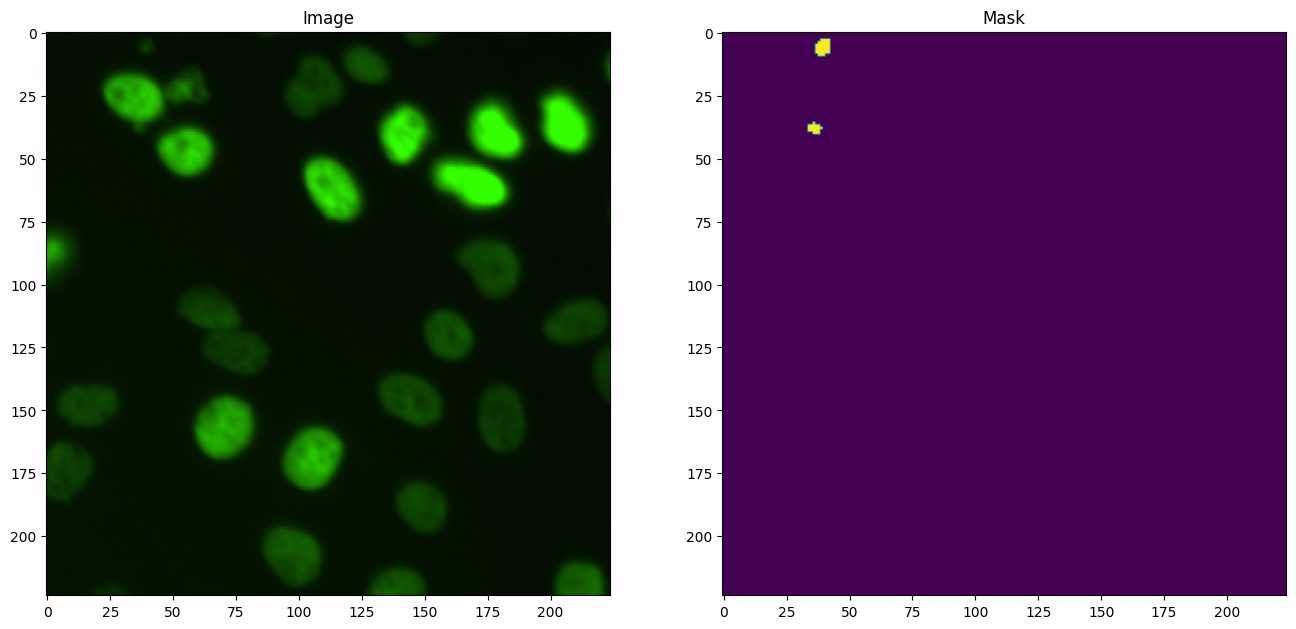

In [ ]:
import matplotlib.pyplot as plt
from torchvision.io import read_image
import numpy as np
#mnMask/data/images/10 Gy_GFP-H2B_A1_1_2023y06m24d_17h57m-11.png
image = read_image("/content/mnMask/data/images/10 Gy_GFP-H2B_A1_1_2023y06m23d_16h57m-26.png")
mask = np.load("mnMask/data/masks/10 Gy_GFP-H2B_A1_1_2023y06m23d_16h57m-26.npy")

plt.figure(figsize=(16, 8))
plt.subplot(121)
plt.title("Image")
plt.imshow(image.permute(1, 2, 0))
plt.subplot(122)
plt.title("Mask")
plt.imshow(mask)

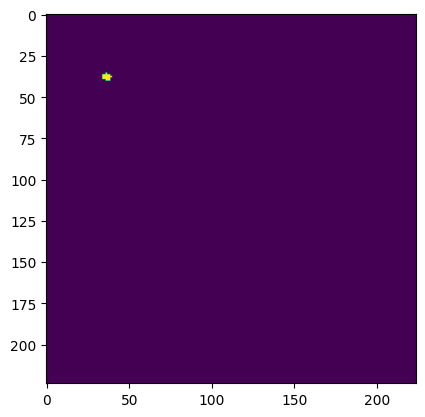

In [ ]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
import torch

a3 = np.array( [[10,10],[100,10],[100,100],[10,100]], dtype=np.int32 )
im = np.zeros([240,320],dtype=np.uint8)
cv2.fillPoly( im, [a3], 255 )

def seperate_semantic_mask(mask):
  '''
  Convert mask that contains all obj into individual mask that
    contain each obj, from semantic seg to instance seg.

  Args:
    im: mask from the dataset

  Returns:
    [im]: list of masks
  '''

  # Convet the mask into binary
  binary_mask = (mask > 0).astype(np.uint8)

  # Find the connected components in the image
  num_labels, labels_im = cv2.connectedComponents(binary_mask)

  # Map component labels to individual masks
  individual_masks = []
  for label in range(1, num_labels):  # Start from 1 to skip the background
    individual_mask = (labels_im == label).astype(np.uint8)
    if individual_mask.sum() < 3: continue
    individual_masks.append(torch.from_numpy(individual_mask))

  # Return the list of individual masks
  return individual_masks

l = seperate_semantic_mask(mask)
binary_mask = (mask > 0).astype(np.uint8)
num_labels, labels_im = cv2.connectedComponents(binary_mask)
plt.imshow(l[1])

In [ ]:
torch.sum(l[1]>0)

tensor(20)

In [ ]:
masks_to_boxes(torch.stack(l))

tensor([[37.,  3., 42.,  9.],
        [34., 36., 39., 40.]])

In [ ]:
import os

cnt = 0
for f in os.listdir("mnMask/data/masks"):
  mask = np.load("mnMask/data/masks/" + f)
  l = seperate_semantic_mask(mask)
  cnt += len(l)
print(f"Total number of micronuclei is: {cnt}.")

Total number of micronuclei is: 1392.


In [ ]:
import os
import torch

from torchvision.io import read_image
from torchvision.ops.boxes import masks_to_boxes
from torchvision import tv_tensors
from torchvision.transforms.v2 import functional as F


class mnMaskDataset(torch.utils.data.Dataset):
    def __init__(self, root, transforms=None):
        self.root = root
        self.transforms = transforms
        # load all image files, sorting them to
        # ensure that they are aligned
        self.imgs = list(sorted(os.listdir(os.path.join(root, "images"))))
        self.masks = list(sorted(os.listdir(os.path.join(root, "masks"))))

    def __getitem__(self, idx):
        # load images and masks
        file_name = self.masks[idx].split(".")[0]
        mask_name = file_name + ".npy"
        img_name = file_name + ".png"
        # print(img_name)
        # print(mask_name)

        img_path = os.path.join(self.root, "images", img_name)
        mask_path = os.path.join(self.root, "masks", mask_name)
        img = read_image(img_path)
        mask = np.load(mask_path)

        # split the color-encoded mask into a set
        # of binary masks
        masks = seperate_semantic_mask(mask)
        if not masks: print(file_name)
        masks = torch.stack(masks)

        # instances are encoded as different colors
        # obj_ids = torch.unique(mask)
        # first id is the background, so remove it
        # obj_ids = obj_ids[1:]
        num_objs = len(masks)
        # print(obj_ids)

        # get bounding box coordinates for each mask
        boxes = masks_to_boxes(masks)
        for box in boxes:
          if box[0] == box[2] or box[1] == box[3]:
            box[2] += 1
            box[3] += 1

        # there is only one class
        labels = torch.ones((num_objs,), dtype=torch.int64)

        image_id = idx
        area = (boxes[:, 3] - boxes[:, 1]) * (boxes[:, 2] - boxes[:, 0])
        # suppose all instances are not crowd
        iscrowd = torch.zeros((num_objs,), dtype=torch.int64)

        # Wrap sample and targets into torchvision tv_tensors:
        img = tv_tensors.Image(img)

        target = {}
        target["boxes"] = tv_tensors.BoundingBoxes(boxes, format="XYXY", canvas_size=F.get_size(img))
        target["masks"] = tv_tensors.Mask(masks)
        target["labels"] = labels
        target["image_id"] = image_id
        target["area"] = area
        target["iscrowd"] = iscrowd

        if self.transforms is not None:
            img, target = self.transforms(img, target)

        return img, target

    def __len__(self):
        return len(self.masks)

In [ ]:
ds = mnMaskDataset('mnMask/data')
print(len(ds))
for i in range(len(ds)):
    box = ds[i][1]['boxes']
    for b in box:
      if b[0] == b[2] and b[1] == b[3]:
        print(ds[i][2])
# list(sorted(os.listdir(os.path.join('data/data', "images"))))[48]

923


# Custom RCNN

### Finetune a pretrained model

In [ ]:
import torchvision
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor

# load a model pre-trained on COCO
model = torchvision.models.detection.fasterrcnn_resnet50_fpn(weights="DEFAULT")

# replace the classifier with a new one, that has
# num_classes which is user-defined
num_classes = 2  # 1 class (person) + background
# get number of input features for the classifier
in_features = model.roi_heads.box_predictor.cls_score.in_features
# replace the pre-trained head with a new one
model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes)

Downloading: "https://download.pytorch.org/models/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth" to /root/.cache/torch/hub/checkpoints/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth
100%|██████████| 160M/160M [00:01<00:00, 95.2MB/s]


In [ ]:
import torchvision
from torchvision.models.detection import FasterRCNN
from torchvision.models.detection.rpn import AnchorGenerator

# load a pre-trained model for classification and return
# only the features
backbone = torchvision.models.mobilenet_v2(weights="DEFAULT").features
# ``FasterRCNN`` needs to know the number of
# output channels in a backbone. For mobilenet_v2, it's 1280
# so we need to add it here
backbone.out_channels = 1280

# let's make the RPN generate 5 x 3 anchors per spatial
# location, with 5 different sizes and 3 different aspect
# ratios. We have a Tuple[Tuple[int]] because each feature
# map could potentially have different sizes and
# aspect ratios
anchor_generator = AnchorGenerator(
    sizes=((32, 64, 128, 256, 512),),
    aspect_ratios=((0.5, 1.0, 2.0),)
)

# let's define what are the feature maps that we will
# use to perform the region of interest cropping, as well as
# the size of the crop after rescaling.
# if your backbone returns a Tensor, featmap_names is expected to
# be [0]. More generally, the backbone should return an
# ``OrderedDict[Tensor]``, and in ``featmap_names`` you can choose which
# feature maps to use.
roi_pooler = torchvision.ops.MultiScaleRoIAlign(
    featmap_names=['0'],
    output_size=7,
    sampling_ratio=2
)

# put the pieces together inside a Faster-RCNN model
model = FasterRCNN(
    backbone,
    num_classes=2,
    rpn_anchor_generator=anchor_generator,
    box_roi_pool=roi_pooler
)

Downloading: "https://download.pytorch.org/models/mobilenet_v2-7ebf99e0.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v2-7ebf99e0.pth
100%|██████████| 13.6M/13.6M [00:00<00:00, 27.1MB/s]


In [ ]:
import torchvision
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
from torchvision.models.detection.mask_rcnn import MaskRCNNPredictor


def get_model_instance_segmentation(num_classes):
    # load an instance segmentation model pre-trained on COCO
    model = torchvision.models.detection.maskrcnn_resnet50_fpn(weights="DEFAULT")

    # get number of input features for the classifier
    in_features = model.roi_heads.box_predictor.cls_score.in_features
    # replace the pre-trained head with a new one
    model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes)

    # now get the number of input features for the mask classifier
    in_features_mask = model.roi_heads.mask_predictor.conv5_mask.in_channels
    hidden_layer = 256
    # and replace the mask predictor with a new one
    model.roi_heads.mask_predictor = MaskRCNNPredictor(
        in_features_mask,
        hidden_layer,
        num_classes
    )

    return model

def get_custom_model_instance_segmentation(num_classes):
    # load an instance segmentation model pre-trained on COCO
    model = torchvision.models.detection.maskrcnn_resnet50_fpn(weights="DEFAULT")

    # get number of input features for the classifier
    in_features = model.roi_heads.box_predictor.cls_score.in_features
    # replace the pre-trained head with a new one
    model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes)

    # now get the number of input features for the mask classifier
    in_features_mask = model.roi_heads.mask_predictor.conv5_mask.in_channels
    hidden_layer = 256
    # and replace the mask predictor with a new one
    model.roi_heads.mask_predictor = MaskRCNNPredictor(
        in_features_mask,
        hidden_layer,
        num_classes
    )

    return model

In [ ]:
os.system("wget https://raw.githubusercontent.com/pytorch/vision/main/references/detection/engine.py")
os.system("wget https://raw.githubusercontent.com/pytorch/vision/main/references/detection/utils.py")
os.system("wget https://raw.githubusercontent.com/pytorch/vision/main/references/detection/coco_utils.py")
os.system("wget https://raw.githubusercontent.com/pytorch/vision/main/references/detection/coco_eval.py")
os.system("wget https://raw.githubusercontent.com/pytorch/vision/main/references/detection/transforms.py")

NameError: name 'os' is not defined

In [ ]:
from torchvision.transforms import v2 as T


def get_transform(train):
    transforms = []
    if train:
        transforms.append(T.RandomHorizontalFlip(0.5))
    transforms.append(T.ToDtype(torch.float, scale=True))
    transforms.append(T.ToPureTensor())
    return T.Compose(transforms)

In [ ]:
import utils

model = torchvision.models.detection.fasterrcnn_resnet50_fpn(weights="DEFAULT")
dataset = mnMaskDataset('mnMask/data', get_transform(train=True))
data_loader = torch.utils.data.DataLoader(
    dataset,
    batch_size=16,
    shuffle=True,
    collate_fn=utils.collate_fn
)

# For Training
images, targets = next(iter(data_loader))
images = list(image for image in images)
targets = [{k: v for k, v in t.items()} for t in targets]
output = model(images, targets)  # Returns losses and detections
print(output)

# For inference
model.eval()
x = [torch.rand(3, 300, 400), torch.rand(3, 500, 400)]
predictions = model(x)  # Returns predictions
print(predictions[0])

In [ ]:
from engine import train_one_epoch, evaluate

# train on the GPU or on the CPU, if a GPU is not available
device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')

# our dataset has two classes only - background and person
num_classes = 2
# use our dataset and defined transformations
dataset = mnMaskDataset('mnMask/data', get_transform(train=True))
dataset_test = mnMaskDataset('mnMask/data', get_transform(train=False))

# split the dataset in train and test set
indices = torch.randperm(len(dataset)).tolist()
dataset = torch.utils.data.Subset(dataset, indices[:-50])
dataset_test = torch.utils.data.Subset(dataset_test, indices[-50:])

# define training and validation data loaders
data_loader = torch.utils.data.DataLoader(
    dataset,
    batch_size=2,
    shuffle=True,
    collate_fn=utils.collate_fn
)

data_loader_test = torch.utils.data.DataLoader(
    dataset_test,
    batch_size=1,
    shuffle=False,
    collate_fn=utils.collate_fnS
)

# get the model using our helper function
model = get_model_instance_segmentation(num_classes)

# move model to the right device
model.to(device)

# construct an optimizer
params = [p for p in model.parameters() if p.requires_grad]
optimizer = torch.optim.SGD(
    params,
    lr=0.005,
    momentum=0.9,
    weight_decay=0.0005
)

# and a learning rate scheduler
lr_scheduler = torch.optim.lr_scheduler.StepLR(
    optimizer,
    step_size=3,
    gamma=0.1
)

# let's train it just for 2 epochs
num_epochs = 20

for epoch in range(num_epochs):
    # train for one epoch, printing every 10 iterations
    train_one_epoch(model, optimizer, data_loader, device, epoch, print_freq=10)
    # update the learning rate
    lr_scheduler.step()
    # evaluate on the test dataset
    evaluate(model, data_loader_test, device=device)

print("That's it!")

Epoch: [0]  [  0/437]  eta: 0:00:43  lr: 0.000016  loss: 3.3690 (3.3690)  loss_classifier: 0.6793 (0.6793)  loss_box_reg: 0.0088 (0.0088)  loss_mask: 0.9509 (0.9509)  loss_objectness: 1.6500 (1.6500)  loss_rpn_box_reg: 0.0800 (0.0800)  time: 0.0995  data: 0.0081  max mem: 2577
Epoch: [0]  [ 10/437]  eta: 0:00:36  lr: 0.000131  loss: 2.4155 (2.6385)  loss_classifier: 0.5574 (0.5170)  loss_box_reg: 0.0317 (0.0395)  loss_mask: 0.9291 (0.9436)  loss_objectness: 0.7374 (1.0489)  loss_rpn_box_reg: 0.0430 (0.0895)  time: 0.0858  data: 0.0077  max mem: 2747
Epoch: [0]  [ 20/437]  eta: 0:00:35  lr: 0.000246  loss: 1.2740 (1.7884)  loss_classifier: 0.2394 (0.3405)  loss_box_reg: 0.0317 (0.0434)  loss_mask: 0.5580 (0.7199)  loss_objectness: 0.1823 (0.6121)  loss_rpn_box_reg: 0.0293 (0.0725)  time: 0.0836  data: 0.0077  max mem: 2765
Epoch: [0]  [ 30/437]  eta: 0:00:34  lr: 0.000360  loss: 0.6605 (1.4144)  loss_classifier: 0.0797 (0.2509)  loss_box_reg: 0.0324 (0.0433)  loss_mask: 0.3936 (0.6122) 

Tested with customized backbone

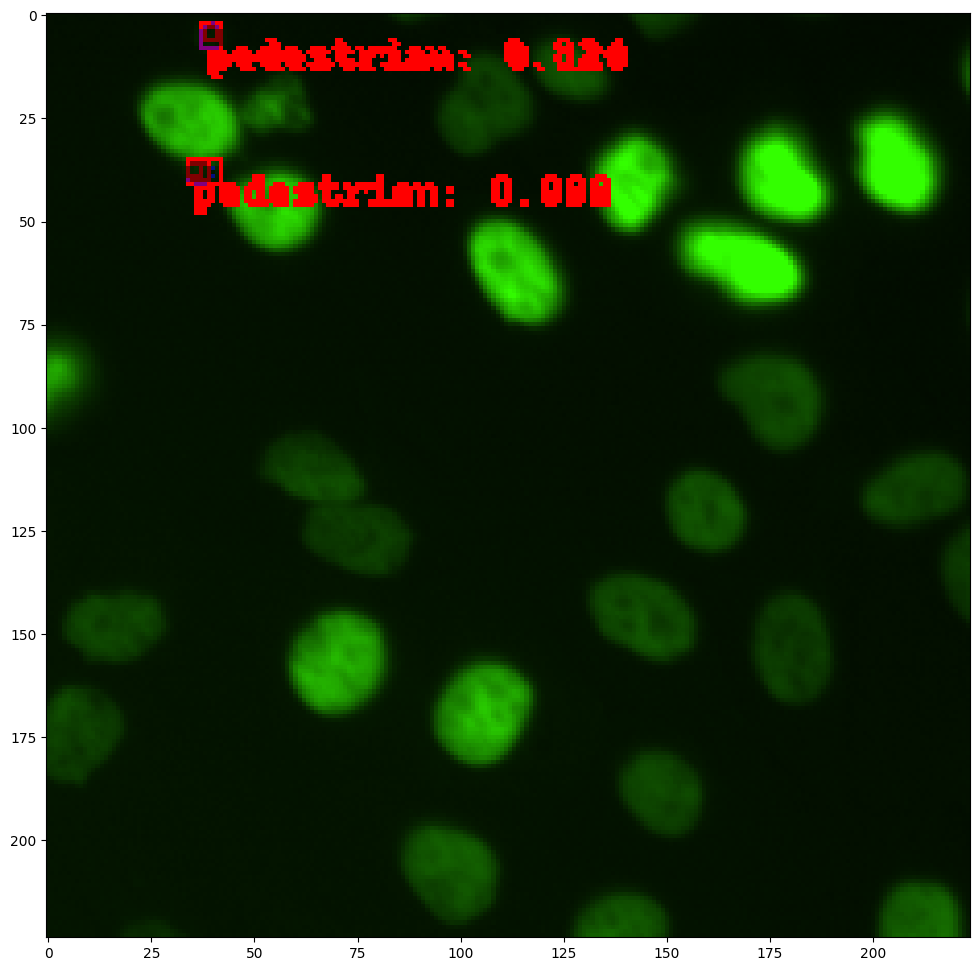

In [ ]:
import matplotlib.pyplot as plt

from torchvision.utils import draw_bounding_boxes, draw_segmentation_masks


image = read_image("mnMask/data/images/10 Gy_GFP-H2B_A1_1_2023y06m23d_16h57m-26.png")
eval_transform = get_transform(train=False)

model.eval()
with torch.no_grad():
    x = eval_transform(image)
    # convert RGBA -> RGB and move to device
    x = x[:3, ...].to(device)
    predictions = model([x, ])
    pred = predictions[0]


image = (255.0 * (image - image.min()) / (image.max() - image.min())).to(torch.uint8)
image = image[:3, ...]
pred_labels = [f"pedestrian: {score:.3f}" for label, score in zip(pred["labels"], pred["scores"])]
pred_boxes = pred["boxes"].long()
output_image = draw_bounding_boxes(image, pred_boxes, pred_labels, colors="red")

masks = (pred["masks"] > 0.7).squeeze(1)
output_image = draw_segmentation_masks(output_image, masks, alpha=0.5, colors="blue")


plt.figure(figsize=(12, 12))
plt.imshow(output_image.permute(1, 2, 0))

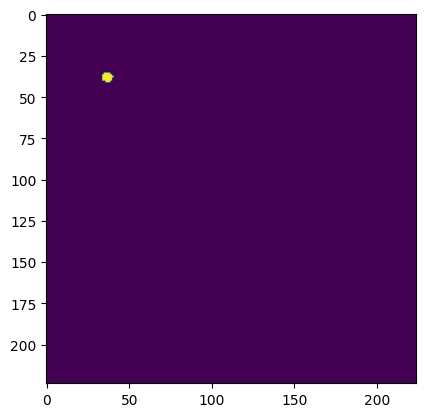

In [ ]:
plt.imshow(masks.cpu()[4])

In [ ]:
torch.save(model.state_dict(), 'RCNN.pt')

In [ ]:
!cp RCNN.pt drive/MyDrive/PMCC/models

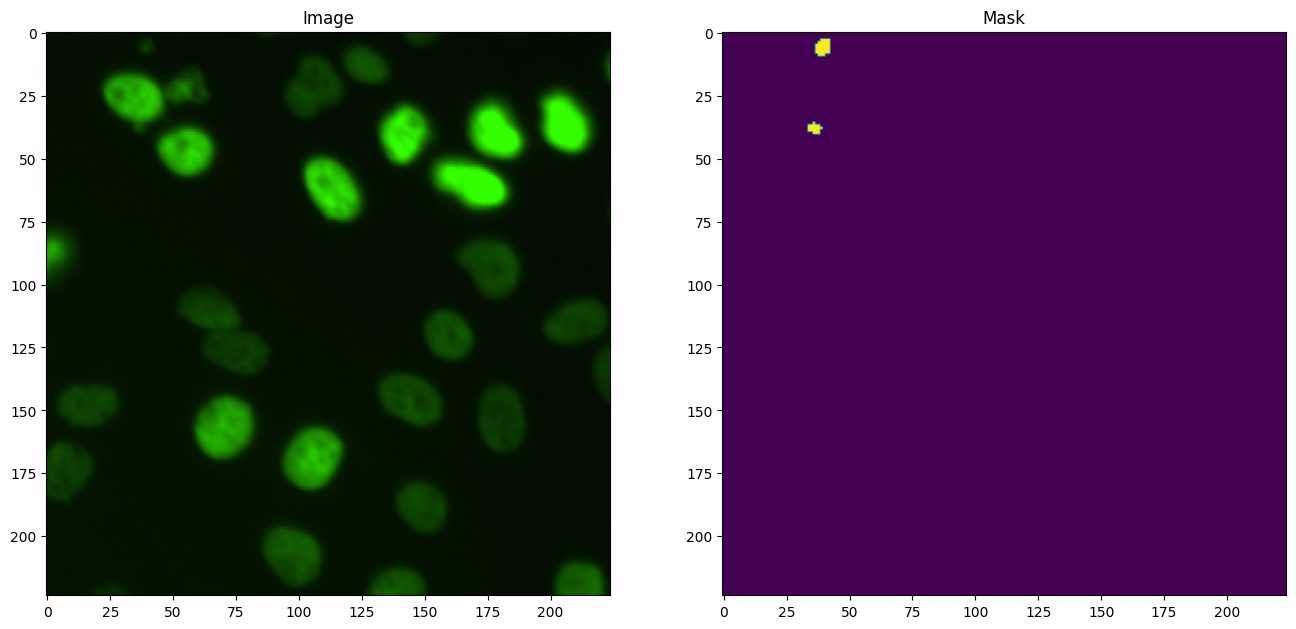

In [ ]:
image = read_image("data/data/images/10 Gy_GFP-H2B_A1_1_2023y06m23d_16h57m-26.png")
mask = np.load("data/data/masks/10 Gy_GFP-H2B_A1_1_2023y06m23d_16h57m-26.npy")

plt.figure(figsize=(16, 8))
plt.subplot(121)
plt.title("Image")
plt.imshow(image.permute(1, 2, 0))
plt.subplot(122)
plt.title("Mask")
plt.imshow(mask)

## New

In [ ]:
!cp /content/drive/MyDrive/PMCC/models/mask-rcnn-resnet50.pt RCNN.pt

!git clone https://github.com/kew6688/MicroNuclei_Detection.git
!pip install -e MicroNuclei_Detection/.

!pip show mn_segmentation

%cd /content/MicroNuclei_Detection

!cd checkpoints && \
./download_ckpts.sh && \
cd ..

Cloning into 'MicroNuclei_Detection'...
remote: Enumerating objects: 842, done.
remote: Counting objects: 100% (236/236), done.
remote: Compressing objects: 100% (168/168), done.
remote: Total 842 (delta 157), reused 129 (delta 65), pack-reused 606 (from 1)
Receiving objects: 100% (842/842), 28.53 MiB | 47.88 MiB/s, done.
Resolving deltas: 100% (513/513), done.
Obtaining file:///content/MicroNuclei_Detection
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
  Building editable for mn_segmentation (pyproject.toml) ... done
  Created wheel for mn_segmentation: filename=mn_segmentation-0.1.0-py2.py3-none-any.whl size=5206 sha256=e5bfa840a34e6fd0967d267ed8e9accbd806ca2518950aff84b7b5e73050ba5f
  Stored in directory: /tmp/pip-ephem-wheel-cache-d6q07xbg/wheels/3f/81/01/c4f05b68a1cbc02396527f710866e1b4827249f9a5d7d4b505
Successfully buil

In [ ]:
!cp /content/drive/MyDrive/PMCC/Dataset/mnMask_v3.zip mnMask_v3.zip
!unzip mnMask_v3.zip -d /content/

流式输出内容被截断，只能显示最后 5000 行内容。
  inflating: /content/mnMask_v3/final_masks/GFP-H2B_A2_1_2023y07m02d_08h02m-1.npy  
  inflating: /content/mnMask_v3/final_masks/10 Gy_GFP-H2B_B1_2_2023y06m25d_11h17m_0.npy  
  inflating: /content/mnMask_v3/final_masks/GFP-H2B_A1_3_2023y07m03d_03h02m-1.npy  
  inflating: /content/mnMask_v3/final_masks/GFP-H2B_A2_1_2023y07m01d_19h02m-0.npy  
  inflating: /content/mnMask_v3/final_masks/10 Gy_GFP-H2B_B1_2_2023y06m26d_02h17m_2.npy  
  inflating: /content/mnMask_v3/final_masks/Plate 1_GFP-H2B_G20_1_2022y12m01d_23h30m-7.npy  
  inflating: /content/mnMask_v3/final_masks/10 Gy_GFP-H2B_A2_1_2023y06m24d_21h17m_0.npy  
  inflating: /content/mnMask_v3/final_masks/GFP-H2B_A3_4_2023y07m03d_08h02m-18.npy  
  inflating: /content/mnMask_v3/final_masks/GFP-H2B_A3_4_2023y07m03d_07h02m-3.npy  
  inflating: /content/mnMask_v3/final_masks/GFP-H2B_A1_1_2023y07m03d_08h02m-10.npy  
  inflating: /content/mnMask_v3/final_masks/GFP-H2B_A3_3_2023y07m02d_21h02m-19.npy  
  inflating: /conte

In [ ]:
!cp /content/drive/MyDrive/PMCC/Dataset/mCherryMask_v4.zip /content/
!unzip /content/mCherryMask_v4.zip -d /content/

Archive:  /content/mCherryMask_v4.zip
   creating: /content/mCherryMask_v4/
   creating: /content/mCherryMask_v4/images/
  inflating: /content/mCherryMask_v4/images/mCherry-H2B_E6_3_2022y08m08d_13h45m-7.png  
  inflating: /content/mCherryMask_v4/images/mCherry-H2B_E6_2_2022y08m08d_13h45m-24.png  
  inflating: /content/mCherryMask_v4/images/mCherry-H2B_E6_2_2022y08m08d_13h45m-23.png  
  inflating: /content/mCherryMask_v4/images/mCherry-H2B_B2_3_2022y08m08d_13h45m-3.png  
  inflating: /content/mCherryMask_v4/images/mCherry-H2B_B2_1_2022y08m08d_13h45m-12.png  
 extracting: /content/mCherryMask_v4/images/mCherry-H2B_E7_1_2022y08m08d_13h45m-12.png  
  inflating: /content/mCherryMask_v4/images/mCherry-H2B_E5_2_2022y08m08d_13h45m-20.png  
  inflating: /content/mCherryMask_v4/images/mCherry-H2B_B4_4_2022y08m08d_13h45m-29.png  
  inflating: /content/mCherryMask_v4/images/mCherry-H2B_B2_3_2022y08m08d_13h45m-14.png  
  inflating: /content/mCherryMask_v4/images/mCherry-H2B_E7_1_2022y08m08d_13h45m-

In [ ]:
import os
os.system("wget https://raw.githubusercontent.com/pytorch/vision/main/references/detection/engine.py")
os.system("wget https://raw.githubusercontent.com/pytorch/vision/main/references/detection/utils.py")
os.system("wget https://raw.githubusercontent.com/pytorch/vision/main/references/detection/coco_utils.py")
os.system("wget https://raw.githubusercontent.com/pytorch/vision/main/references/detection/coco_eval.py")
os.system("wget https://raw.githubusercontent.com/pytorch/vision/main/references/detection/transforms.py")

0

In [ ]:
import os
import torch
import numpy as np
import utils

from torchvision.io import read_image
from torchvision.ops.boxes import masks_to_boxes
from torchvision import tv_tensors
from torchvision.transforms.v2 import functional as F

import torchvision
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
from torchvision.models.detection.mask_rcnn import MaskRCNNPredictor
from torchvision.transforms import v2 as T
from engine import train_one_epoch, evaluate


### Dataloader

In [ ]:
def get_transform(train):
    transforms = []
    if train:
        transforms.append(T.RandomHorizontalFlip(0.5))
    transforms.append(T.ToDtype(torch.float, scale=True))
    transforms.append(T.ToPureTensor())
    return T.Compose(transforms)

def get_transform_grey(train):
    transforms = []
    if train:
        transforms.append(T.RandomHorizontalFlip(0.5))
        transforms.append(T.Grayscale(num_output_channels=1))
    transforms.append(T.ToDtype(torch.float, scale=True))
    transforms.append(T.ToPureTensor())
    return T.Compose(transforms)

def get_transform_jitter(train):
    transforms = []
    if train:
        transforms.append(T.RandomHorizontalFlip(0.5))
        transforms.append(T.ColorJitter(brightness=.3, contrast=.3, saturation=.3, hue=.5))
        transforms.append(T.GaussianBlur(kernel_size=(5, 9), sigma=(0.1, 2.)))
    transforms.append(T.ToDtype(torch.float, scale=True))
    transforms.append(T.ToPureTensor())
    return T.Compose(transforms)


class mnMaskDataset(torch.utils.data.Dataset):
    def __init__(self, root, transforms=None):
        self.root = root
        self.transforms = transforms
        # load all image files, sorting them to
        # ensure that they are aligned
        self.imgs = list(sorted(os.listdir(os.path.join(root, "images"))))
        self.masks = os.listdir(os.path.join(root, "final_masks"))

    def __getitem__(self, idx):
        # load images and masks
        file_name = self.masks[idx].split(".")[0]
        mask_name = file_name + ".npy"
        img_name = file_name + ".png"
        # print(img_name)
        # print(mask_name)

        img_path = os.path.join(self.root, "images", img_name)
        mask_path = os.path.join(self.root, "final_masks", mask_name)
        img = read_image(img_path)
        masks = np.load(mask_path).squeeze()
        if masks.ndim == 2:
          masks = np.expand_dims(masks, axis=0)

        masks = masks.astype(np.uint8)
        masks = torch.from_numpy(masks)

        # instances are encoded as different colors
        # obj_ids = torch.unique(mask)
        # first id is the background, so remove it
        # obj_ids = obj_ids[1:]
        num_objs = len(masks)
        # print(obj_ids)

        # get bounding box coordinates for each mask
        boxes = masks_to_boxes(masks)
        for box in boxes:
          if box[0] == box[2] or box[1] == box[3]:
            box[2] += 1
            box[3] += 1

        # there is only one class
        labels = torch.ones((num_objs,), dtype=torch.int64)

        image_id = idx
        area = (boxes[:, 3] - boxes[:, 1]) * (boxes[:, 2] - boxes[:, 0])
        # suppose all instances are not crowd
        iscrowd = torch.zeros((num_objs,), dtype=torch.int64)

        # Wrap sample and targets into torchvision tv_tensors:
        img = tv_tensors.Image(img)

        target = {}
        target["boxes"] = tv_tensors.BoundingBoxes(boxes, format="XYXY", canvas_size=F.get_size(img))
        target["masks"] = tv_tensors.Mask(masks)
        target["labels"] = labels
        target["image_id"] = image_id
        target["area"] = area
        target["iscrowd"] = iscrowd

        if self.transforms is not None:
            img, target = self.transforms(img, target)

        return img, target

    def __len__(self):
        return len(self.masks)

In [ ]:
import matplotlib.pyplot as plt

def get_transform_test(train,brightness=0,contrast=0,saturation=0,hue=0,blur=0):
    transforms = []
    if train:
        # transforms.append(T.RandomHorizontalFlip(0.5))
        # transforms.append(T.ColorJitter(brightness=brightness, contrast=contrast, saturation=saturation, hue=hue))
        transforms.append(T.GaussianBlur(kernel_size=(5, 9), sigma=blur))
    transforms.append(T.ToDtype(torch.float, scale=True))
    transforms.append(T.ToPureTensor())
    return T.Compose(transforms)

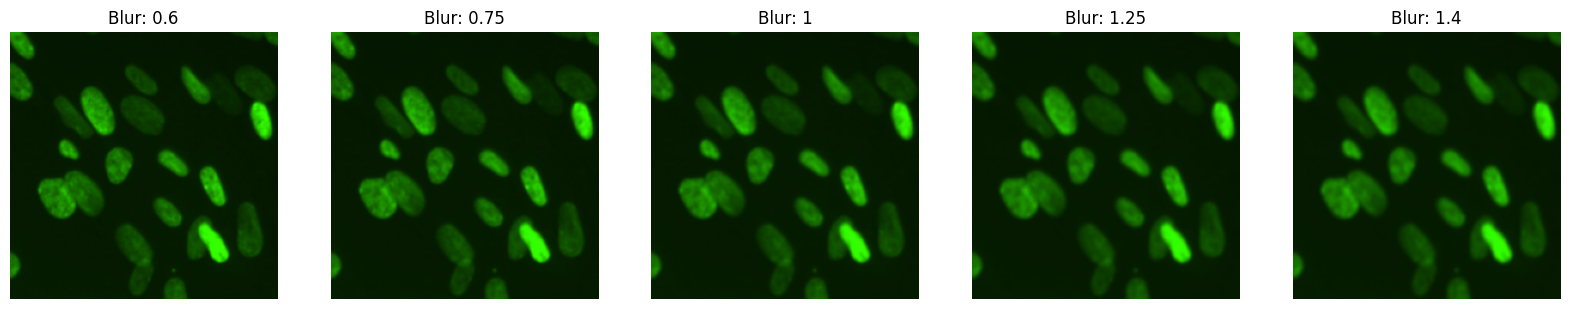

In [ ]:
range = [-0.4, -0.25, 0, 0.25, 0.4]
fig, axs = plt.subplots(1, 5, figsize=(20, 4))

for i,ax in enumerate(axs):
  dataset = mnMaskDataset("/content/mnMask_v2", get_transform_test(train=True,blur=(1+range[i],1+range[i]+0.001)))
  # np.array(dataset[0][0]).shape
  ax.imshow(np.array(dataset[0][0]).transpose(1,2,0))
  ax.set_axis_off()
  ax.set_title(f"Blur: {1+range[i]}")

### train before

In [ ]:
def get_model_instance_segmentation(num_classes):
    # load an instance segmentation model pre-trained on COCO
    model = torchvision.models.detection.maskrcnn_resnet50_fpn(weights="DEFAULT")

    # get number of input features for the classifier
    in_features = model.roi_heads.box_predictor.cls_score.in_features
    # replace the pre-trained head with a new one
    model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes)

    # now get the number of input features for the mask classifier
    in_features_mask = model.roi_heads.mask_predictor.conv5_mask.in_channels
    hidden_layer = 256
    # and replace the mask predictor with a new one
    model.roi_heads.mask_predictor = MaskRCNNPredictor(
        in_features_mask,
        hidden_layer,
        num_classes
    )

    return model

In [ ]:
# train on the GPU or on the CPU, if a GPU is not available
device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')

# our dataset has two classes only - background and mn
num_classes = 2
# use our dataset and defined transformations
dataset = mnMaskDataset('mnMask/data', get_transform(train=True))
dataset_test = mnMaskDataset('mnMask/data', get_transform(train=False))

# split the dataset in train and test set
indices = torch.randperm(len(dataset)).tolist()
dataset = torch.utils.data.Subset(dataset, indices[:-100])
dataset_test = torch.utils.data.Subset(dataset_test, indices[-100:])

# define training and validation data loaders
data_loader = torch.utils.data.DataLoader(
    dataset,
    batch_size=16,
    shuffle=True,
    collate_fn=utils.collate_fn
)

data_loader_test = torch.utils.data.DataLoader(
    dataset_test,
    batch_size=16,
    shuffle=False,
    collate_fn=utils.collate_fn
)

# get the model using our helper function
model = get_model_instance_segmentation(num_classes)

# move model to the right device
model.to(device)

# construct an optimizer
params = [p for p in model.parameters() if p.requires_grad]
optimizer = torch.optim.SGD(
    params,
    lr=0.005,
    momentum=0.9,
    weight_decay=0.0005
)

# and a learning rate scheduler
lr_scheduler = torch.optim.lr_scheduler.StepLR(
    optimizer,
    step_size=3,
    gamma=0.1
)

# let's train it just for 2 epochs
num_epochs = 20

for epoch in range(num_epochs):
    # train for one epoch, printing every 10 iterations
    train_one_epoch(model, optimizer, data_loader, device, epoch, print_freq=10)
    # update the learning rate
    lr_scheduler.step()
    # evaluate on the test dataset
    evaluate(model, data_loader_test, device=device)

print("That's it!")

/content/engine.py:30: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=scaler is not None):


Epoch: [0]  [ 0/37]  eta: 0:01:43  lr: 0.000144  loss: 7.6705 (7.6705)  loss_classifier: 0.7935 (0.7935)  loss_box_reg: 0.0241 (0.0241)  loss_mask: 1.9872 (1.9872)  loss_objectness: 4.4463 (4.4463)  loss_rpn_box_reg: 0.4193 (0.4193)  time: 2.8032  data: 0.0522  max mem: 11653
Epoch: [0]  [10/37]  eta: 0:01:16  lr: 0.001531  loss: 1.0681 (2.5095)  loss_classifier: 0.2537 (0.3649)  loss_box_reg: 0.0534 (0.0454)  loss_mask: 0.5594 (0.8418)  loss_objectness: 0.3475 (1.1052)  loss_rpn_box_reg: 0.0995 (0.1522)  time: 2.8152  data: 0.0471  max mem: 11826
Epoch: [0]  [20/37]  eta: 0:00:47  lr: 0.002919  loss: 0.8910 (1.6093)  loss_classifier: 0.0894 (0.2271)  loss_box_reg: 0.0577 (0.0539)  loss_mask: 0.3756 (0.5870)  loss_objectness: 0.1387 (0.6154)  loss_rpn_box_reg: 0.0835 (0.1260)  time: 2.7722  data: 0.0459  max mem: 11826
Epoch: [0]  [30/37]  eta: 0:00:19  lr: 0.004306  loss: 0.5807 (1.2709)  loss_classifier: 0.0580 (0.1712)  loss_box_reg: 0.0639 (0.0577)  loss_mask: 0.2708 (0.4837)  loss

In [ ]:
torch.save(model.state_dict(), 'mask-rcnn-resnet50.pt')
!cp mask-rcnn-resnet50.pt drive/MyDrive/PMCC/models

In [ ]:
i,t = dataset[0]
t["masks"].astype("uint8")

AttributeError: 'Tensor' object has no attribute 'astype'

### models

In [ ]:
from torchvision.models.detection.faster_rcnn import _default_anchorgen, FasterRCNN, FastRCNNConvFCHead, RPNHead
from torchvision.models.detection.rpn import AnchorGenerator

def get_model_instance_segmentation(num_classes):
    # load an instance segmentation model pre-trained on COCO
    model = torchvision.models.detection.maskrcnn_resnet50_fpn(weights="DEFAULT")

    #create a custom anchor_generator for the FPN
    sizes = ((4,), (8,), (16,), (32,), (64,))
    aspect_ratios = ((0.25, 0.5, 1.0, 2.0, 4.0),) * len(sizes)
    anchor_generator = AnchorGenerator(sizes=sizes, aspect_ratios=aspect_ratios)

    model.rpn.anchor_generator = anchor_generator

    # 256 because that's the number of features that FPN returns
    model.rpn.head = RPNHead(256, anchor_generator.num_anchors_per_location()[0])

    # get the number of input features for the classifier
    in_features = model.roi_heads.box_predictor.cls_score.in_features

    # number of class in our dataset
    num_classes = 2

    # replace the pre-trained head with a new one
    model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes)

    # now get the number of input features for the mask classifier
    in_features_mask = model.roi_heads.mask_predictor.conv5_mask.in_channels
    hidden_layer = 256

    # and replace the mask predictor with a new one
    model.roi_heads.mask_predictor = MaskRCNNPredictor(in_features_mask,
                                                    hidden_layer,num_classes)
    return model

In [ ]:
import torchvision
from torchvision.models.detection import FasterRCNN, MaskRCNN
from torchvision.models.detection.rpn import AnchorGenerator

def get_model_instance_segmentation(num_classes):
    backbone = torchvision.models.mobilenet_v2(weights="DEFAULT").features
    # ``FasterRCNN`` needs to know the number of
    # output channels in a backbone. For mobilenet_v2, it's 1280
    # so we need to add it here
    backbone.out_channels = 1280

    # let's make the RPN generate 5 x 3 anchors per spatial
    # location, with 5 different sizes and 3 different aspect
    # ratios. We have a Tuple[Tuple[int]] because each feature
    # map could potentially have different sizes and
    # aspect ratios
    anchor_generator = AnchorGenerator(
        sizes=((32, 64, 128),),
        aspect_ratios=((0.5, 1.0, 2.0),)
    )

    # let's define what are the feature maps that we will
    # use to perform the region of interest cropping, as well as
    # the size of the crop after rescaling.
    # if your backbone returns a Tensor, featmap_names is expected to
    # be [0]. More generally, the backbone should return an
    # ``OrderedDict[Tensor]``, and in ``featmap_names`` you can choose which
    # feature maps to use.
    roi_pooler = torchvision.ops.MultiScaleRoIAlign(
        featmap_names=['0'],
        output_size=7,
        sampling_ratio=2
    )

    # put the pieces together inside a Mask-RCNN model
    model = MaskRCNN(
        backbone,
        num_classes=num_classes,
        rpn_anchor_generator=anchor_generator,
        box_roi_pool=roi_pooler
    )
    return model

In [ ]:
"""
Custom mask rcnn based on PyTorch MaskRCNN class. The class is copied to prevent future change in library.
This code is adapted from PyTorch MaskRCNN implementation.
"""

from collections import OrderedDict
from typing import Any, Callable, Optional

from torch import nn
import torchvision
from torchvision.ops import MultiScaleRoIAlign

from torchvision.ops import misc as misc_nn_ops
from torchvision.transforms._presets import ObjectDetection
from torchvision.models._api import register_model, Weights, WeightsEnum
from torchvision.models._meta import _COCO_CATEGORIES
from torchvision.models._utils import _ovewrite_value_param, handle_legacy_interface
from torchvision.models.resnet import resnet50, ResNet50_Weights
from torchvision.models.resnet import resnet50, ResNet50_Weights
from torchvision.models.detection.rpn import AnchorGenerator
from torchvision.models.detection.backbone_utils import resnet_fpn_backbone, _resnet_fpn_extractor, _validate_trainable_layers
from torchvision.models.detection.faster_rcnn import _default_anchorgen, FasterRCNN, FastRCNNConvFCHead, RPNHead, FastRCNNPredictor
from torchvision.models.detection.mask_rcnn import MaskRCNN

__all__ = [
    "MaskRCNN",
    "MaskRCNN_ResNet50_FPN_Weights",
    "MaskRCNN_ResNet50_FPN_V2_Weights",
    "maskrcnn_resnet50_fpn",
    "maskrcnn_resnet50_fpn_v2",
]



class MaskRCNNHeads(nn.Sequential):
    _version = 2

    def __init__(self, in_channels, layers, dilation, norm_layer: Optional[Callable[..., nn.Module]] = None):
        """
        Args:
            in_channels (int): number of input channels
            layers (list): feature dimensions of each FCN layer
            dilation (int): dilation rate of kernel
            norm_layer (callable, optional): Module specifying the normalization layer to use. Default: None
        """
        blocks = []
        next_feature = in_channels
        for layer_features in layers:
            blocks.append(
                misc_nn_ops.Conv2dNormActivation(
                    next_feature,
                    layer_features,
                    kernel_size=3,
                    stride=1,
                    padding=dilation,
                    dilation=dilation,
                    norm_layer=norm_layer,
                )
            )
            next_feature = layer_features

        super().__init__(*blocks)
        for layer in self.modules():
            if isinstance(layer, nn.Conv2d):
                nn.init.kaiming_normal_(layer.weight, mode="fan_out", nonlinearity="relu")
                if layer.bias is not None:
                    nn.init.zeros_(layer.bias)

    def _load_from_state_dict(
        self,
        state_dict,
        prefix,
        local_metadata,
        strict,
        missing_keys,
        unexpected_keys,
        error_msgs,
    ):
        version = local_metadata.get("version", None)

        if version is None or version < 2:
            num_blocks = len(self)
            for i in range(num_blocks):
                for type in ["weight", "bias"]:
                    old_key = f"{prefix}mask_fcn{i+1}.{type}"
                    new_key = f"{prefix}{i}.0.{type}"
                    if old_key in state_dict:
                        state_dict[new_key] = state_dict.pop(old_key)

        super()._load_from_state_dict(
            state_dict,
            prefix,
            local_metadata,
            strict,
            missing_keys,
            unexpected_keys,
            error_msgs,
        )


class MaskRCNNPredictor(nn.Sequential):
    def __init__(self, in_channels, dim_reduced, num_classes):
        super().__init__(
            OrderedDict(
                [
                    ("conv5_mask", nn.ConvTranspose2d(in_channels, dim_reduced, 2, 2, 0)),
                    ("relu", nn.ReLU(inplace=True)),
                    ("mask_fcn_logits", nn.Conv2d(dim_reduced, num_classes, 1, 1, 0)),
                ]
            )
        )

        for name, param in self.named_parameters():
            if "weight" in name:
                nn.init.kaiming_normal_(param, mode="fan_out", nonlinearity="relu")
            # elif "bias" in name:
            #     nn.init.constant_(param, 0)

_COMMON_META = {
    "categories": _COCO_CATEGORIES,
    "min_size": (1, 1),
}

class MaskRCNN_ResNet50_FPN_V2_Weights(WeightsEnum):
    COCO_V1 = Weights(
        url="https://download.pytorch.org/models/maskrcnn_resnet50_fpn_v2_coco-73cbd019.pth",
        transforms=ObjectDetection,
        meta={
            **_COMMON_META,
            "num_params": 46359409,
            "recipe": "https://github.com/pytorch/vision/pull/5773",
            "_metrics": {
                "COCO-val2017": {
                    "box_map": 47.4,
                    "mask_map": 41.8,
                }
            },
            "_ops": 333.577,
            "_file_size": 177.219,
            "_docs": """These weights were produced using an enhanced training recipe to boost the model accuracy.""",
        },
    )
    DEFAULT = COCO_V1


@handle_legacy_interface(
    weights=("pretrained", MaskRCNN_ResNet50_FPN_V2_Weights.COCO_V1),
    weights_backbone=("pretrained_backbone", ResNet50_Weights.IMAGENET1K_V1),
)
def maskrcnn_resnet50_fpn(
    *,
    weights: None,
    progress: bool = True,
    num_classes: Optional[int] = None,
    weights_backbone: Optional[ResNet50_Weights] = None,
    trainable_backbone_layers: Optional[int] = None,
    **kwargs: Any,
) -> MaskRCNN:
    """custom wrapper for PyTorch maskrcnn_resnet50_fpn_v2
        change ROI_generator and hyperparameters.
    """
    weights = MaskRCNN_ResNet50_FPN_V2_Weights.verify(weights)
    weights_backbone = ResNet50_Weights.verify(weights_backbone)

    if weights is not None:
        weights_backbone = None
        num_classes = _ovewrite_value_param("num_classes", num_classes, len(weights.meta["categories"]))
    elif num_classes is None:
        num_classes = 91

    is_trained = weights is not None or weights_backbone is not None
    trainable_backbone_layers = _validate_trainable_layers(is_trained, trainable_backbone_layers, 5, 3)

    backbone = resnet50(weights=weights_backbone, progress=progress)
    backbone = _resnet_fpn_extractor(backbone, trainable_backbone_layers, norm_layer=nn.BatchNorm2d)
    rpn_anchor_generator = _default_anchorgen()
    rpn_head = RPNHead(backbone.out_channels, rpn_anchor_generator.num_anchors_per_location()[0], conv_depth=2)
    box_head = FastRCNNConvFCHead(
        (backbone.out_channels, 7, 7), [256, 256, 256, 256], [1024], norm_layer=nn.BatchNorm2d
    )
    mask_head = MaskRCNNHeads(backbone.out_channels, [256, 256, 256, 256], 1, norm_layer=nn.BatchNorm2d)
    model = MaskRCNN(
        backbone,
        num_classes=num_classes,
        rpn_anchor_generator=rpn_anchor_generator,
        rpn_head=rpn_head,
        box_head=box_head,
        mask_head=mask_head,
        **kwargs,
    )

    if weights is not None:
        model.load_state_dict(weights.get_state_dict(progress=progress, check_hash=True))

    ##############################################################
    # after load pre-trained weight, custom model parts load here#
    ##############################################################

    #create a custom anchor_generator for the FPN
    sizes = ((4,), (8,), (16,), (32,), (64,))
    aspect_ratios = ((0.25, 0.5, 1.0, 2.0, 4.0),) * len(sizes)
    anchor_generator = AnchorGenerator(sizes=sizes, aspect_ratios=aspect_ratios)

    model.rpn.anchor_generator = anchor_generator

    # 256 because that's the number of features that FPN returns
    model.rpn.head = RPNHead(256, anchor_generator.num_anchors_per_location()[0])

    # custom RPN NMS
    model.rpn.rpn_nms_thresh = 0.5

    # get the number of input features for the classifier
    in_features = model.roi_heads.box_predictor.cls_score.in_features

    # number of class in our dataset
    num_classes = 2

    # replace the pre-trained head with a new one
    model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes)

    # custom box NMS
    model.roi_heads.box_nms_thresh = 0.2

    # now get the number of input features for the mask classifier
    in_features_mask = model.roi_heads.mask_predictor.conv5_mask.in_channels
    hidden_layer = 256

    # and replace the mask predictor with a new one
    model.roi_heads.mask_predictor = MaskRCNNPredictor(in_features_mask,
                                                    hidden_layer,num_classes)
    return model


def maskrcnn_mobile(
    *,
    num_classes: Optional[int] = None,
    **kwargs: Any,
) -> MaskRCNN:
    """custom wrapper for PyTorch maskrcnn_resnet50_fpn_v2
        change ROI_generator and hyperparameters.
    """
    backbone = torchvision.models.mobilenet_v2(weights="DEFAULT").features
    # ``FasterRCNN`` needs to know the number of
    # output channels in a backbone. For mobilenet_v2, it's 1280
    # so we need to add it here
    backbone.out_channels = 1280

    # let's make the RPN generate 5 x 3 anchors per spatial
    # location, with 5 different sizes and 3 different aspect
    # ratios. We have a Tuple[Tuple[int]] because each feature
    # map could potentially have different sizes and
    # aspect ratios
    anchor_generator = AnchorGenerator(
        sizes=((32, 64, 128),),
        aspect_ratios=((0.5, 1.0, 2.0),)
    )

    # let's define what are the feature maps that we will
    # use to perform the region of interest cropping, as well as
    # the size of the crop after rescaling.
    # if your backbone returns a Tensor, featmap_names is expected to
    # be [0]. More generally, the backbone should return an
    # ``OrderedDict[Tensor]``, and in ``featmap_names`` you can choose which
    # feature maps to use.
    roi_pooler = torchvision.ops.MultiScaleRoIAlign(
        featmap_names=['0'],
        output_size=7,
        sampling_ratio=2
    )

    mask_head = MaskRCNNHeads(backbone.out_channels, [256, 256, 256, 256], 1, norm_layer=nn.BatchNorm2d)

    # put the pieces together inside a Mask-RCNN model
    model = MaskRCNN(
        backbone,
        num_classes=num_classes,
        rpn_anchor_generator=anchor_generator,
        box_roi_pool=roi_pooler,
        mask_head=mask_head,
        **kwargs,
    )
    return model

def maskrcnn_resnet(name, num_classes, pretrained, res='normal'):
    print('Using maskrcnn with {} backbone...'.format(name))

    backbone = resnet_fpn_backbone(name, pretrained=pretrained, trainable_layers=5)


    sizes = ((4,), (8,), (16,), (32,), (64,))
    aspect_ratios = ((0.25, 0.5, 1.0, 2.0, 4.0),) * len(sizes)
    anchor_generator = AnchorGenerator(
        sizes=sizes, aspect_ratios=aspect_ratios
    )

    roi_pooler = torchvision.ops.MultiScaleRoIAlign(featmap_names=['0', '1', '2', '3'],
                                                    output_size=7, sampling_ratio=2)


    model = MaskRCNN(backbone, num_classes=num_classes,
                    rpn_anchor_generator=anchor_generator, box_roi_pool=roi_pooler)

    model.roi_heads.box_nms_thresh = 0.2
    model.rpn.rpn_nms_thresh = 0.5
    return model

### Trainer

Run load Dataset, New, then Trainer

In [ ]:
from mn_segmentation.tests.evaluator import Evaluator
from mn_segmentation.tests.test import evaluate_mn_dataset
from mn_segmentation.lib.Application import Application
# from mn_segmentation.dataset.mnMask import mnMaskDataset

import os
from PIL import Image
import numpy as np
from torchvision.transforms.functional import pil_to_tensor
from tqdm import tqdm
import matplotlib.pyplot as plt
import argparse
import time

batch_sz = 16
num_worker = 2

def evaluate_mn_dataset(model, dataset_path, evaluator, nms_iou=0.2, conf=0.4, mask_conf=0.7, ap_iou=0.5):
  for file in tqdm(os.listdir(os.path.join(dataset_path,'final_masks'))[-300:]):
    # get final pred, may need customize model predict function
    im = Image.open(os.path.join(dataset_path,'images',file[:-4]+".png"))
    image = pil_to_tensor(im)
    pred = model._predict(image)
    pred_boxes,pred_masks,pred_scores = model._post_process(pred, conf)
    pred_boxes = pred_boxes.cpu().numpy()
    pred_masks = pred_masks.cpu().numpy()
    pred_masks = (pred_masks > mask_conf).squeeze(1)       # shape [n,w,h]
    pred_scores = pred_scores.cpu().numpy()           # shape [n]
    if pred_masks.ndim == 2:
      pred_masks = np.expand_dims(pred_masks, axis=0)
    # print(pred_masks.shape)
    # print(pred_scores.shape)

    # get GT mask
    gt_masks = np.load(os.path.join(dataset_path,'final_masks',file))  # shape [n,w,h]
    # obj_ids = np.unique(gt_masks)[1:]
    # gt_masks = (gt_masks == obj_ids[:, None, None])
    gt_masks.squeeze()
    if gt_masks.ndim == 2:
      gt_masks = np.expand_dims(gt_masks, axis=0)
    # if len(gt_masks) < 4:
    #   continue
    # compare and update
    recall = evaluator.update(pred_masks, pred_scores, gt_masks, ap_iou)

    # uncomment this can give bad cases that cause recall drop, missing mn
    # if recall < 0.5:
    #   print(recall,file)
  if evaluator.predictions == 0 or evaluator.TP == 0:
    return
  evaluator.finalize()
  # evaluator.draw_pr_curve()
  return

def trainer_mrcnn(name, model, epoch, dataset_path, cp_path, transform, data_loader=None, optimizer=None):
    # train on the GPU or on the CPU, if a GPU is not available
    device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')

    if not os.path.exists(cp_path):
        os.makedirs(cp_path)

    # our dataset has two classes only - background and mn
    num_classes = 2

    if data_loader is None:
      # use our dataset and defined transformations
      dataset = mnMaskDataset(dataset_path, transform(train=True))
      dataset_test = mnMaskDataset(dataset_path, transform(train=False))

      # split the dataset in train and test set
      indices = torch.randperm(len(dataset)).tolist()
      indices = list(range(len(dataset))
      dataset = torch.utils.data.Subset(dataset, indices[:-300])
      dataset_test = torch.utils.data.Subset(dataset_test, indices[-300:])

      # define training and validation data loaders
      data_loader = torch.utils.data.DataLoader(
          dataset,
          batch_size=batch_sz,
          shuffle=True,
          collate_fn=utils.collate_fn,
          num_workers=num_worker
      )

      data_loader_test = torch.utils.data.DataLoader(
          dataset_test,
          batch_size=4,
          shuffle=False,
          collate_fn=utils.collate_fn
      )

    # get the model using our helper function
    model = model

    # move model to the right device
    model.to(device)

    # construct an optimizer
    params = [p for p in model.parameters() if p.requires_grad]
    torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

    optimizer = torch.optim.AdamW(params, lr=1e-4, weight_decay=1e-4)

    # optimizer = torch.optim.SGD(
    #     params,
    #     lr=0.005,
    #     momentum=0.9,
    #     weight_decay=0.0005
    # )

    # and a learning rate scheduler
    # lr_scheduler = torch.optim.lr_scheduler.StepLR(
    #     optimizer,
    #     step_size=3,
    #     gamma=0.1
    # )

    num_epochs = epoch

    for epoch in range(num_epochs):
        # train for one epoch, printing every 10 iterations
        train_one_epoch(model, optimizer, data_loader, device, epoch, print_freq=10)
        # update the learning rate
        # lr_scheduler.step()
        # evaluate on the test dataset
        # evaluate(model, data_loader_test, device=device)

        if (epoch+1)%10 == 0:
          print(f"++++++++++++ Save model {name}-{epoch+1} +++++++++++++++++")
          path = os.path.join(cp_path, f'{name}-{epoch+1}.pt')
          torch.save(model.state_dict(), path)

          app = Application(model=model, device=torch.device('cuda'))
          for i in range(7,8):
            print(f"**********************************************")
            print(f"**** conf: {i/10} ************************")
            print("**********************************************")
            evaluator = Evaluator()
            for j in range(5,6):
              print(f"*********** mask_conf: {j/10} ************")
              evaluate_mn_dataset(app, dataset_path, evaluator, conf=i/10, mask_conf=j/10, ap_iou=0.5)
    print("That's it!")

In [ ]:
swin_backbone = create_model('swin_base_patch4_window7_224', pretrained=True, features_only=True)
type(swin_backbone)

timm.models._features.FeatureListNet

In [ ]:
swin_backbone = SwinBackbonePermute(
        img_size=224,  # Update based on your use case
        patch_size=4,
        window_size=7,
        embed_dim=128,
        depths=(2, 2, 18, 2),
        num_heads=(4, 8, 16, 32),
        num_classes=0,  # Backbone-only
        pretrained=True,
        features_only=True
    )
swin_backbone

SwinBackbonePermute(
  (patch_embed): PatchEmbed(
    (proj): Conv2d(3, 128, kernel_size=(4, 4), stride=(4, 4))
    (norm): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
  )
  (layers): Sequential(
    (0): SwinTransformerStage(
      (downsample): Identity()
      (blocks): Sequential(
        (0): SwinTransformerBlock(
          (norm1): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
          (attn): WindowAttention(
            (qkv): Linear(in_features=128, out_features=384, bias=True)
            (attn_drop): Dropout(p=0.0, inplace=False)
            (proj): Linear(in_features=128, out_features=128, bias=True)
            (proj_drop): Dropout(p=0.0, inplace=False)
            (softmax): Softmax(dim=-1)
          )
          (drop_path1): Identity()
          (norm2): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
          (mlp): Mlp(
            (fc1): Linear(in_features=128, out_features=512, bias=True)
            (act): GELU(approximate='none')
         

In [ ]:
print(swin_backbone.feature_info.channels())

[128, 256, 512, 1024]


In [ ]:
# Print layer names
for name, module in swin_backbone.named_children():
    print(name)

patch_embed
layers_0
layers_1
layers_2
layers_3


In [ ]:
model = create_model('swin_base_patch4_window7_224.ms_in22k', pretrained=True)
# model = model.eval()
# # print(model)
# dummy_input = torch.randn(1, 3, 224, 224)  # Batch size 1, 3 channels, 224x224 image
# output = model(dummy_input)
# print(output)
# for i, feature in enumerate(output):
#     print(f"Feature {i}: shape {feature.shape}")

In [ ]:
import torch, gc
from torchvision.models.detection import MaskRCNN
from torchvision.models.detection.backbone_utils import BackboneWithFPN
from torchvision.ops.feature_pyramid_network import FeaturePyramidNetwork
from timm import create_model
!mkdir -p /content/checkpoints/

import torch.nn as nn

class SwinBackboneWrapper(nn.ModuleDict):
    def __init__(self, model):
        layers = OrderedDict()
        for name, module in model.named_children():
            layers[name] = module

        super().__init__(layers)


from timm.models.swin_transformer import SwinTransformer
import torch.nn as nn

class SwinBackbonePermute(SwinTransformer):
    def __init__(self, *args, **kwargs):
        super(SwinBackbonePermute, self).__init__(*args, **kwargs)

    def forward_features(self, x):
        features = super().forward_features(x)  # Get feature maps from the original method

        # Permute each feature map to [B, C, W, H]
        permuted_features = {
            key: feature.permute(0, 3, 1, 2) for key, feature in features.items()
        }
        return permuted_features

import warnings
from typing import Callable, Dict, List, Optional, Union
from collections import OrderedDict

from torch import nn, Tensor
from torchvision.ops import misc as misc_nn_ops
from torchvision.ops.feature_pyramid_network import ExtraFPNBlock, FeaturePyramidNetwork, LastLevelMaxPool

class IntermediateLayerGetter(nn.ModuleDict):
    """
    Module wrapper that returns intermediate layers from a model

    It has a strong assumption that the modules have been registered
    into the model in the same order as they are used.
    This means that one should **not** reuse the same nn.Module
    twice in the forward if you want this to work.

    Additionally, it is only able to query submodules that are directly
    assigned to the model. So if `model` is passed, `model.feature1` can
    be returned, but not `model.feature1.layer2`.

    Args:
        model (nn.Module): model on which we will extract the features
        return_layers (Dict[name, new_name]): a dict containing the names
            of the modules for which the activations will be returned as
            the key of the dict, and the value of the dict is the name
            of the returned activation (which the user can specify).

    Examples::

        >>> m = torchvision.models.resnet18(weights=ResNet18_Weights.DEFAULT)
        >>> # extract layer1 and layer3, giving as names `feat1` and feat2`
        >>> new_m = torchvision.models._utils.IntermediateLayerGetter(m,
        >>>     {'layer1': 'feat1', 'layer3': 'feat2'})
        >>> out = new_m(torch.rand(1, 3, 224, 224))
        >>> print([(k, v.shape) for k, v in out.items()])
        >>>     [('feat1', torch.Size([1, 64, 56, 56])),
        >>>      ('feat2', torch.Size([1, 256, 14, 14]))]
    """

    _version = 2
    __annotations__ = {
        "return_layers": Dict[str, str],
    }

    def __init__(self, model: nn.Module, return_layers: Dict[str, str]) -> None:
        if not set(return_layers).issubset([name for name, _ in model.named_children()]):
            raise ValueError("return_layers are not present in model")
        orig_return_layers = return_layers
        return_layers = {str(k): str(v) for k, v in return_layers.items()}
        layers = OrderedDict()
        for name, module in model.named_children():
            layers[name] = module
            if name in return_layers:
                del return_layers[name]
            if not return_layers:
                break

        super().__init__(layers)
        self.return_layers = orig_return_layers

    def forward(self, x):
        out = OrderedDict()
        for name, module in self.items():
            x = module(x)
            if name in self.return_layers:
                out_name = self.return_layers[name]
                out[out_name] = x.permute(0, 3, 1, 2)
        return out

class BackboneWithFPN(nn.Module):
    """
    Adds a FPN on top of a model.
    Internally, it uses torchvision.models._utils.IntermediateLayerGetter to
    extract a submodel that returns the feature maps specified in return_layers.
    The same limitations of IntermediateLayerGetter apply here.
    Args:
        backbone (nn.Module)
        return_layers (Dict[name, new_name]): a dict containing the names
            of the modules for which the activations will be returned as
            the key of the dict, and the value of the dict is the name
            of the returned activation (which the user can specify).
        in_channels_list (List[int]): number of channels for each feature map
            that is returned, in the order they are present in the OrderedDict
        out_channels (int): number of channels in the FPN.
        norm_layer (callable, optional): Module specifying the normalization layer to use. Default: None
    Attributes:
        out_channels (int): the number of channels in the FPN
    """

    def __init__(
        self,
        backbone: nn.Module,
        return_layers: Dict[str, str],
        in_channels_list: List[int],
        out_channels: int,
        extra_blocks: Optional[ExtraFPNBlock] = None,
        norm_layer: Optional[Callable[..., nn.Module]] = None,
    ) -> None:
        super().__init__()

        if extra_blocks is None:
            extra_blocks = LastLevelMaxPool()

        self.body = IntermediateLayerGetter(backbone, return_layers=return_layers)
        self.fpn = FeaturePyramidNetwork(
            in_channels_list=in_channels_list,
            out_channels=out_channels,
            extra_blocks=extra_blocks,
            norm_layer=norm_layer,
        )
        self.out_channels = out_channels

    def forward(self, x: Tensor) -> Dict[str, Tensor]:
        x = self.body(x)
        x = self.fpn(x)
        return x


def maskrcnn_swin(name='swin', num_classes=2, res='normal'):
    print('Using maskrcnn with {} backbone...'.format(name))

    # Load pre-trained Swin Transformer from timm
    swin_backbone = create_model('swin_base_patch4_window7_224', pretrained=True, features_only=True)
    # swin_backbone = torchvision.models.swin_t().features

    # Check output channels from Swin Transformer to configure the FPN
    print(swin_backbone.feature_info.channels())  # Example: [128, 256, 512, 1024]

    # Create FPN from Swin Transformer
    in_channels_list = swin_backbone.feature_info.channels()  # Input channels for FPN
    out_channels = 256  # Desired output channels for FPN layers

    returned_layers = [0, 1, 2, 3]
    return_layers = {f"layers_{k}": str(v) for v, k in enumerate(returned_layers)}

    # Define the backbone with FPN
    backbone = BackboneWithFPN(
        swin_backbone,
        return_layers=return_layers,
        in_channels_list=in_channels_list,
        out_channels=out_channels,
    )

    # custom anchor
    sizes = ((4,), (8,), (16,), (32,), (64,))
    aspect_ratios = ((0.25, 0.5, 1.0, 2.0, 4.0),) * len(sizes)
    anchor_generator = AnchorGenerator(
        sizes=sizes, aspect_ratios=aspect_ratios
    )

    roi_pooler = torchvision.ops.MultiScaleRoIAlign(featmap_names=['0', '1', '2', '3'],
                                                    output_size=7, sampling_ratio=2)


    model = MaskRCNN(backbone, min_size=224, num_classes=num_classes,
                    rpn_anchor_generator=anchor_generator, box_roi_pool=roi_pooler,
                    # custom iou
                    rpn_fg_iou_thresh=0.5,
                    rpn_bg_iou_thresh=0.5)

    model.roi_heads.box_nms_thresh = 0.2
    model.rpn.rpn_nms_thresh = 0.5
    return model

epoch = 200

print("===========================================")
print("swin_fpn")
print("===========================================")
model = maskrcnn_swin()
# print(model)
# dummy_input = torch.randn(1, 3, 224, 224)  # Batch size 1, 3 channels, 224x224 image
# model.eval()
# output = model(dummy_input)
# print(output)
# model1.load_state_dict(torch.load("/content/checkpoints/maskrcnn-resnet50-fpn-empty-10.pt"))
trainer_mrcnn('maskrcnn-swin-fpn-v2', model, epoch, transform=get_transform, dataset_path="/content/mnMask_v3/", cp_path="/content/checkpoints/")

swin_fpn
Using maskrcnn with swin backbone...


/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/353M [00:00<?, ?B/s]

[128, 256, 512, 1024]


NameError: name 'AnchorGenerator' is not defined

In [ ]:
# @title train swin
from mn_segmentation.models.mask_rcnn import maskrcnn_mobile, maskrcnn_resnet, maskrcnn_resnet50_fpn, maskrcnn_swin

print("===========================================")
print("swin_fpn")
print("===========================================")
model = maskrcnn_swin()
trainer_mrcnn('maskrcnn-swin-fpn-v3', model, epoch=200, transform=get_transform_jitter, dataset_path="/content/mnMask_v3/", cp_path="/content/drive/MyDrive/PMCC/checkpoints")

swin_fpn
Using maskrcnn with swin backbone...


/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/353M [00:00<?, ?B/s]

[128, 256, 512, 1024]


/content/MicroNuclei_Detection/engine.py:30: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=scaler is not None):


...

100%|██████████| 300/300 [00:16<00:00, 18.47it/s]

mAP: 0.9686704140356872
precision: 0.8322884012539185
recall: 0.8322884012539185
f1: 0.8322884012539185


Epoch: [190]  [ 0/96]  eta: 0:01:20  lr: 0.000100  loss: 0.2366 (0.2366)  loss_classifier: 0.0095 (0.0095)  loss_box_reg: 0.0295 (0.0295)  loss_mask: 0.1945 (0.1945)  loss_objectness: 0.0018 (0.0018)  loss_rpn_box_reg: 0.0012 (0.0012)  time: 0.8432  data: 0.4246  max mem: 7213
Epoch: [190]  [10/96]  eta: 0:00:37  lr: 0.000100  loss: 0.2395 (0.2421)  loss_classifier: 0.0059 (0.0060)  loss_box_reg: 0.0263 (0.0242)  loss_mask: 0.2093 (0.2102)  loss_objectness: 0.0005 (0.0009)  loss_rpn_box_reg: 0.0009 (0.0009)  time: 0.4379  data: 0.0637  max mem: 7213
Epoch: [190]  [20/96]  eta: 0:00:31  lr: 0.000100  loss: 0.2401 (0.2416)  loss_classifier: 0.0059 (0.0061)  loss_box_reg: 0.0234 (0.0239)  loss_mask: 0.2037 (0.2098)  loss_objectness: 0.0004 (0.0008)  loss_rpn_box_reg: 0.0008 (0.0009)  time: 0.3980  data: 0.0277  max mem: 7213
Epoch: [190]  [30/96]  eta: 0:00:27  lr: 0.000100  loss: 0.2401 (0.2408)  loss_classifier: 0.0055 (0.0060)  loss_box_reg: 0.0210 (0.0231)  loss_mask: 0.2037 (0.2100) 

100%|██████████| 300/300 [00:16<00:00, 18.60it/s]

mAP: 0.9785399925828675
precision: 0.8722397476340694
recall: 0.8667711598746082
f1: 0.869496855345912
That's it!


In [ ]:
!cp -av /content/checkpoints/. /content/drive/MyDrive/PMCC/checkpoints

In [ ]:
# @title train resnet50
from mn_segmentation.models.mask_rcnn import maskrcnn_mobile, maskrcnn_resnet, maskrcnn_resnet50_fpn, maskrcnn_swin

print("===========================================")
print("resnet50fpn")
print("===========================================")
model1 = maskrcnn_resnet50_fpn(weights="DEFAULT")
# model1.load_state_dict(torch.load("/content/checkpoints/maskrcnn-resnet50-jitter-v2-60.pt"))
trainer_mrcnn('maskrcnn-resnet50-v3', model1, epoch=200, transform=get_transform_jitter, dataset_path="/content/mnMask_v3/", cp_path="/content/drive/MyDrive/PMCC/checkpoints")
# clean gpu ram
del model1
gc.collect()
torch.cuda.empty_cache()

resnet50fpn


Downloading: "https://download.pytorch.org/models/maskrcnn_resnet50_fpn_v2_coco-73cbd019.pth" to /root/.cache/torch/hub/checkpoints/maskrcnn_resnet50_fpn_v2_coco-73cbd019.pth
100%|██████████| 177M/177M [00:00<00:00, 215MB/s]
/content/MicroNuclei_Detection/engine.py:30: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=scaler is not None):


Epoch: [0]  [ 0/96]  eta: 0:05:45  lr: 0.000001  loss: 2.2325 (2.2325)  loss_classifier: 0.8296 (0.8296)  loss_box_reg: 0.0052 (0.0052)  loss_mask: 0.6957 (0.6957)  loss_objectness: 0.6926 (0.6926)  loss_rpn_box_reg: 0.0093 (0.0093)  time: 3.6020  data: 0.6018  max mem: 18856
Epoch: [0]  [10/96]  eta: 0:01:13  lr: 0.000012  loss: 2.0601 (2.0205)  loss_classifier: 0.7047 (0.6688)  loss_box_reg: 0.0036 (0.0036)  loss_mask: 0.6221 (0.6482)  loss_objectness: 0.6924 (0.6923)  loss_rpn_box_reg: 0.0069 (0.0076)  time: 0.8572  data: 0.0774  max mem: 19195
Epoch: [0]  [20/96]  eta: 0:00:55  lr: 0.000022  loss: 1.6306 (1.6896)  loss_classifier: 0.3262 (0.4209)  loss_box_reg: 0.0035 (0.0034)  loss_mask: 0.5564 (0.5665)  loss_objectness: 0.6914 (0.6912)  loss_rpn_box_reg: 0.0075 (0.0077)  time: 0.5812  data: 0.0266  max mem: 19195
Epoch: [0]  [30/96]  eta: 0:00:44  lr: 0.000033  loss: 1.1341 (1.4926)  loss_classifier: 0.0406 (0.2939)  loss_box_reg: 0.0025 (0.0031)  loss_mask: 0.3956 (0.4986)  loss

100%|██████████| 300/300 [00:13<00:00, 22.38it/s]

mAP: 0.8169358680603667
precision: 0.711864406779661
recall: 0.7241379310344828
f1: 0.717948717948718


...

mAP: 0.9703882296552765
precision: 0.928125
recall: 0.9310344827586207
f1: 0.9295774647887324


Epoch: [120]  [ 0/96]  eta: 0:01:35  lr: 0.000100  loss: 0.1024 (0.1024)  loss_classifier: 0.0022 (0.0022)  loss_box_reg: 0.0066 (0.0066)  loss_mask: 0.0934 (0.0934)  loss_objectness: 0.0000 (0.0000)  loss_rpn_box_reg: 0.0002 (0.0002)  time: 0.9954  data: 0.4154  max mem: 20020
Epoch: [120]  [10/96]  eta: 0:00:53  lr: 0.000100  loss: 0.1153 (0.1124)  loss_classifier: 0.0027 (0.0032)  loss_box_reg: 0.0115 (0.0131)  loss_mask: 0.0934 (0.0954)  loss_objectness: 0.0001 (0.0003)  loss_rpn_box_reg: 0.0003 (0.0004)  time: 0.6248  data: 0.0632  max mem: 20020
Epoch: [120]  [20/96]  eta: 0:00:46  lr: 0.000100  loss: 0.1140 (0.1140)  loss_classifier: 0.0031 (0.0033)  loss_box_reg: 0.0115 (0.0128)  loss_mask: 0.0975 (0.0973)  loss_objectness: 0.0001 (0.0003)  loss_rpn_box_reg: 0.0004 (0.0004)  time: 0.5867  data: 0.0278  max mem: 20020
Epoch: [120]  [30/96]  eta: 0:00:39  lr: 0.000100  loss: 0.1147 (0.1147)  loss_classifier: 0.0030 (0.0031)  loss_box_reg: 0.0113 (0.0124)  loss_mask: 0.0996 (0.098

100%|██████████| 300/300 [00:10<00:00, 28.23it/s]

mAP: 0.9800822891430174
precision: 0.9390625
recall: 0.9420062695924765
f1: 0.9405320813771518


Epoch: [130]  [ 0/96]  eta: 0:01:37  lr: 0.000100  loss: 0.1212 (0.1212)  loss_classifier: 0.0043 (0.0043)  loss_box_reg: 0.0110 (0.0110)  loss_mask: 0.1055 (0.1055)  loss_objectness: 0.0001 (0.0001)  loss_rpn_box_reg: 0.0002 (0.0002)  time: 1.0112  data: 0.4373  max mem: 20020
Epoch: [130]  [10/96]  eta: 0:00:53  lr: 0.000100  loss: 0.1127 (0.1118)  loss_classifier: 0.0035 (0.0036)  loss_box_reg: 0.0116 (0.0115)  loss_mask: 0.0978 (0.0963)  loss_objectness: 0.0001 (0.0002)  loss_rpn_box_reg: 0.0002 (0.0003)  time: 0.6240  data: 0.0644  max mem: 20020
Epoch: [130]  [20/96]  eta: 0:00:46  lr: 0.000100  loss: 0.1107 (0.1128)  loss_classifier: 0.0030 (0.0035)  loss_box_reg: 0.0123 (0.0131)  loss_mask: 0.0924 (0.0955)  loss_objectness: 0.0002 (0.0004)  loss_rpn_box_reg: 0.0003 (0.0003)  time: 0.5879  data: 0.0293  max mem: 20020
Epoch: [130]  [30/96]  eta: 0:00:39  lr: 0.000100  loss: 0.1116 (0.1134)  loss_classifier: 0.0027 (0.0035)  loss_box_reg: 0.0123 (0.0131)  loss_mask: 0.0946 (0.096

In [ ]:
!cp -av /content/checkpoints/. /content/drive/MyDrive/PMCC/checkpoints

In [ ]:
# @title train resnext101
from mn_segmentation.models.mask_rcnn import maskrcnn_mobile, maskrcnn_resnet, maskrcnn_resnet50_fpn, maskrcnn_swin

print("===========================================")
print("resnext101_32x8d")
print("===========================================")
model3 = maskrcnn_resnet("resnext101_32x8d", num_classes=2, pretrained=True)
trainer_mrcnn('maskrcnn-resnext101-v3', model3, epoch=200, transform=get_transform_jitter, dataset_path="/content/mnMask_v3/", cp_path="/content/drive/MyDrive/PMCC/checkpoints")


resnext101_32x8d
Using maskrcnn with resnext101_32x8d backbone...


/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:135: UserWarning: Using 'backbone_name' as positional parameter(s) is deprecated since 0.13 and may be removed in the future. Please use keyword parameter(s) instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNeXt101_32X8D_Weights.IMAGENET1K_V1`. You can also use `weights=ResNeXt101_32X8D_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/resnext101_32x8d-8ba56ff5.pth" to /root/.cache/torch/hub/c

Epoch: [0]  [ 0/96]  eta: 0:06:43  lr: 0.000001  loss: 2.6613 (2.6613)  loss_classifier: 0.8153 (0.8153)  loss_box_reg: 0.0004 (0.0004)  loss_mask: 1.1372 (1.1372)  loss_objectness: 0.6982 (0.6982)  loss_rpn_box_reg: 0.0103 (0.0103)  time: 4.1996  data: 0.5519  max mem: 29042
Epoch: [0]  [10/96]  eta: 0:01:52  lr: 0.000012  loss: 2.0046 (2.0576)  loss_classifier: 0.6016 (0.5899)  loss_box_reg: 0.0002 (0.0002)  loss_mask: 0.7024 (0.7666)  loss_objectness: 0.6933 (0.6936)  loss_rpn_box_reg: 0.0068 (0.0072)  time: 1.3065  data: 0.0767  max mem: 29863
Epoch: [0]  [20/96]  eta: 0:01:28  lr: 0.000022  loss: 1.4567 (1.6858)  loss_classifier: 0.2763 (0.3851)  loss_box_reg: 0.0002 (0.0004)  loss_mask: 0.4903 (0.6100)  loss_objectness: 0.6843 (0.6836)  loss_rpn_box_reg: 0.0059 (0.0067)  time: 1.0124  data: 0.0282  max mem: 29863
Epoch: [0]  [30/96]  eta: 0:01:13  lr: 0.000033  loss: 1.0971 (1.4798)  loss_classifier: 0.0623 (0.2734)  loss_box_reg: 0.0007 (0.0006)  loss_mask: 0.3938 (0.5386)  loss

100%|██████████| 300/300 [00:19<00:00, 15.55it/s]

mAP: 0.8810722075345633
precision: 0.792156862745098
recall: 0.6352201257861635
f1: 0.7050610820244329


...

mAP: 0.975517138388046
precision: 0.9004739336492891
recall: 0.8962264150943396
f1: 0.8983451536643027


Epoch: [150]  [ 0/96]  eta: 0:02:19  lr: 0.000100  loss: 0.1060 (0.1060)  loss_classifier: 0.0026 (0.0026)  loss_box_reg: 0.0091 (0.0091)  loss_mask: 0.0936 (0.0936)  loss_objectness: 0.0005 (0.0005)  loss_rpn_box_reg: 0.0001 (0.0001)  time: 1.4547  data: 0.4496  max mem: 30331
Epoch: [150]  [10/96]  eta: 0:01:31  lr: 0.000100  loss: 0.1060 (0.1059)  loss_classifier: 0.0036 (0.0038)  loss_box_reg: 0.0104 (0.0113)  loss_mask: 0.0898 (0.0905)  loss_objectness: 0.0000 (0.0001)  loss_rpn_box_reg: 0.0002 (0.0003)  time: 1.0609  data: 0.0641  max mem: 30331
Epoch: [150]  [20/96]  eta: 0:01:19  lr: 0.000100  loss: 0.1077 (0.1066)  loss_classifier: 0.0034 (0.0036)  loss_box_reg: 0.0114 (0.0123)  loss_mask: 0.0894 (0.0904)  loss_objectness: 0.0000 (0.0001)  loss_rpn_box_reg: 0.0003 (0.0003)  time: 1.0222  data: 0.0267  max mem: 30331
Epoch: [150]  [30/96]  eta: 0:01:08  lr: 0.000100  loss: 0.1080 (0.1071)  loss_classifier: 0.0034 (0.0038)  loss_box_reg: 0.0124 (0.0126)  loss_mask: 0.0881 (0.090

100%|██████████| 300/300 [00:18<00:00, 15.81it/s]

mAP: 0.9767444348693067
precision: 0.9073783359497645
recall: 0.9088050314465409
f1: 0.9080911233307148


Epoch: [160]  [ 0/96]  eta: 0:02:23  lr: 0.000100  loss: 0.1093 (0.1093)  loss_classifier: 0.0057 (0.0057)  loss_box_reg: 0.0168 (0.0168)  loss_mask: 0.0864 (0.0864)  loss_objectness: 0.0000 (0.0000)  loss_rpn_box_reg: 0.0003 (0.0003)  time: 1.4953  data: 0.4850  max mem: 30331
Epoch: [160]  [10/96]  eta: 0:01:31  lr: 0.000100  loss: 0.1040 (0.1028)  loss_classifier: 0.0036 (0.0035)  loss_box_reg: 0.0104 (0.0110)  loss_mask: 0.0875 (0.0878)  loss_objectness: 0.0001 (0.0002)  loss_rpn_box_reg: 0.0002 (0.0002)  time: 1.0644  data: 0.0672  max mem: 30331
Epoch: [160]  [20/96]  eta: 0:01:19  lr: 0.000100  loss: 0.1031 (0.1022)  loss_classifier: 0.0032 (0.0033)  loss_box_reg: 0.0098 (0.0109)  loss_mask: 0.0881 (0.0876)  loss_objectness: 0.0001 (0.0001)  loss_rpn_box_reg: 0.0002 (0.0002)  time: 1.0216  data: 0.0266  max mem: 30331
Epoch: [160]  [30/96]  eta: 0:01:08  lr: 0.000100  loss: 0.1044 (0.1038)  loss_classifier: 0.0033 (0.0035)  loss_box_reg: 0.0128 (0.0122)  loss_mask: 0.0883 (0.087

In [ ]:
!cp -av /content/checkpoints/. /content/drive/MyDrive/PMCC/checkpoints

In [ ]:
from google.colab import runtime
runtime.unassign()

In [ ]:
model = maskrcnn_resnet50_fpn(weights=None)
dummy_input = torch.randn(1, 3, 224, 224)  # Batch size 1, 3 channels, 224x224 image
output = model.backbone.body(dummy_input)

In [ ]:
# @title train abalation
import torch, gc
from mn_segmentation.models.mask_rcnn import maskrcnn_mobile, maskrcnn_resnet, maskrcnn_resnet50_fpn
# from mn_segmentation.train.mrcnn_pytorch_train import trainer_mrcnn

epoch = 50
!mkdir -p /content/checkpoints/

print("===========================================")
print("resnet50fpn")
print("===========================================")
model1 = maskrcnn_resnet50_fpn(weights="DEFAULT", c_anchor=False, c_rpn_nms=0.7, c_box_nms=0.5)
# model1.load_state_dict(torch.load("/content/checkpoints/maskrcnn-resnet50-fpn-empty-10.pt"))
trainer_mrcnn('maskrcnn-resnet50-fpn-empty', model1, epoch, transform=get_transform, dataset_path="/content/mnMask_v3/", cp_path="/content/drive/MyDrive/PMCC/checkpoints")
# clean gpu ram
del model1
gc.collect()
torch.cuda.empty_cache()

print("===========================================")
print("resnet50fpn anchor")
print("===========================================")
model1 = maskrcnn_resnet50_fpn(weights="DEFAULT", c_anchor=True, c_rpn_nms=0.7, c_box_nms=0.5)
# model1.load_state_dict(torch.load("/content/checkpoints/maskrcnn-resnet50-fpn-anchor-ablation-10.pt"))
trainer_mrcnn('maskrcnn-resnet50-fpn-anchor-ablation', model1, epoch, transform=get_transform, dataset_path="/content/mnMask_v3/", cp_path="/content/drive/MyDrive/PMCC/checkpoints")
# clean gpu ram
del model1
gc.collect()
torch.cuda.empty_cache()

epoch = 50
print("===========================================")
print("resnet50fpn iou")
print("===========================================")
model1 = maskrcnn_resnet50_fpn(weights="DEFAULT", c_anchor=False, c_rpn_nms=0.7, c_box_nms=0.5,
                  rpn_fg_iou_thresh=0.5,
                  rpn_bg_iou_thresh=0.5)
trainer_mrcnn('maskrcnn-resnet50-fpn-nms-ablation', model1, epoch, transform=get_transform, dataset_path="/content/mnMask_v3/", cp_path="/content/drive/MyDrive/PMCC/checkpoints")
# clean gpu ram
del model1
gc.collect()
torch.cuda.empty_cache()

# print("===========================================")
# print("resnet50fpn")
# print("===========================================")
# model1 = maskrcnn_resnet50_fpn(weights="DEFAULT")
# trainer_mrcnn('maskrcnn-resnet50-grey-v2', model1, epoch, transform=get_transform_grey, dataset_path="/content/mnMask_v2/", cp_path="/content/checkpoints/")
# # clean gpu ram
# del model1
# gc.collect()
# torch.cuda.empty_cache()

# print("===========================================")
# print("resnet50fpn")
# print("===========================================")
# model1 = maskrcnn_resnet50_fpn(weights="DEFAULT")
# model1.load_state_dict(torch.load("/content/checkpoints/maskrcnn-resnet50-jitter-v2-60.pt"))
# trainer_mrcnn('maskrcnn-resnet50-jitter-v2-60', model1, epoch, transform=get_transform_jitter, dataset_path="/content/mnMask_v2/", cp_path="/content/checkpoints/")
# # clean gpu ram
# del model1
# gc.collect()
# torch.cuda.empty_cache()

# print("===========================================")
# print("mobilenet")
# print("===========================================")
# model2 = maskrcnn_mobile(num_classes=2)
# trainer_mrcnn('mask-rcnn-mobile', model2, epoch, dataset_path="/content/mnMask_v2/", cp_path="/content/checkpoints/")
# # clean gpu
# del model2
# gc.collect()
# torch.cuda.empty_cache()

# print("===========================================")
# print("resnext101_32x8d")
# print("===========================================")
# model3 = maskrcnn_resnet("resnext101_32x8d", num_classes=2, pretrained=True)
# trainer_mrcnn('mask-rcnn-resnext101fpn-roi-nms-v2', model3, epoch, dataset_path="/content/mnMask_v2/", cp_path="/content/checkpoints/")

# !cp /content/mrcnn_output.txt /content/drive/MyDrive/PMCC/models
# !cp -av /content/checkpoints/. /content/drive/MyDrive/PMCC/checkpoints
from google.colab import runtime
runtime.unassign()

resnet50fpn


Downloading: "https://download.pytorch.org/models/maskrcnn_resnet50_fpn_v2_coco-73cbd019.pth" to /root/.cache/torch/hub/checkpoints/maskrcnn_resnet50_fpn_v2_coco-73cbd019.pth
100%|██████████| 177M/177M [00:00<00:00, 202MB/s]
/content/MicroNuclei_Detection/engine.py:30: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=scaler is not None):


Epoch: [0]  [ 0/96]  eta: 0:05:30  lr: 0.000001  loss: 4.1178 (4.1178)  loss_classifier: 0.8099 (0.8099)  loss_box_reg: 0.0112 (0.0112)  loss_mask: 1.8070 (1.8070)  loss_objectness: 1.2543 (1.2543)  loss_rpn_box_reg: 0.2352 (0.2352)  time: 3.4432  data: 0.2180  max mem: 19693
Epoch: [0]  [10/96]  eta: 0:01:14  lr: 0.000012  loss: 3.3401 (3.4963)  loss_classifier: 0.7025 (0.6652)  loss_box_reg: 0.0175 (0.0178)  loss_mask: 1.7465 (1.7252)  loss_objectness: 0.8471 (0.9046)  loss_rpn_box_reg: 0.1912 (0.1834)  time: 0.8641  data: 0.0451  max mem: 20039
Epoch: [0]  [20/96]  eta: 0:00:56  lr: 0.000022  loss: 2.7192 (2.8623)  loss_classifier: 0.3497 (0.4364)  loss_box_reg: 0.0224 (0.0241)  loss_mask: 1.4685 (1.4679)  loss_objectness: 0.6706 (0.7606)  loss_rpn_box_reg: 0.1579 (0.1733)  time: 0.6053  data: 0.0272  max mem: 20039
Epoch: [0]  [30/96]  eta: 0:00:45  lr: 0.000033  loss: 1.5105 (2.2839)  loss_classifier: 0.0814 (0.3186)  loss_box_reg: 0.0412 (0.0329)  loss_mask: 0.8061 (1.1897)  loss

100%|██████████| 300/300 [00:11<00:00, 26.20it/s]

mAP: 0.9438954777837346
precision: 0.8422664624808576
recall: 0.8647798742138365
f1: 0.8533747090768038


...

100%|██████████| 300/300 [00:10<00:00, 28.78it/s]

mAP: 0.9837905736705753
precision: 0.926905132192846
recall: 0.9371069182389937
f1: 0.9319781078967943


Epoch: [40]  [ 0/96]  eta: 0:01:19  lr: 0.000100  loss: 0.2031 (0.2031)  loss_classifier: 0.0094 (0.0094)  loss_box_reg: 0.0378 (0.0378)  loss_mask: 0.1396 (0.1396)  loss_objectness: 0.0038 (0.0038)  loss_rpn_box_reg: 0.0125 (0.0125)  time: 0.8277  data: 0.2197  max mem: 21647
Epoch: [40]  [10/96]  eta: 0:00:54  lr: 0.000100  loss: 0.1927 (0.1918)  loss_classifier: 0.0094 (0.0088)  loss_box_reg: 0.0302 (0.0320)  loss_mask: 0.1360 (0.1361)  loss_objectness: 0.0024 (0.0027)  loss_rpn_box_reg: 0.0125 (0.0122)  time: 0.6297  data: 0.0439  max mem: 21647
Epoch: [40]  [20/96]  eta: 0:00:47  lr: 0.000100  loss: 0.1819 (0.1878)  loss_classifier: 0.0086 (0.0086)  loss_box_reg: 0.0302 (0.0317)  loss_mask: 0.1305 (0.1331)  loss_objectness: 0.0018 (0.0025)  loss_rpn_box_reg: 0.0106 (0.0119)  time: 0.6099  data: 0.0265  max mem: 21647
Epoch: [40]  [30/96]  eta: 0:00:40  lr: 0.000100  loss: 0.1762 (0.1812)  loss_classifier: 0.0082 (0.0082)  loss_box_reg: 0.0281 (0.0297)  loss_mask: 0.1236 (0.1295)  

100%|██████████| 300/300 [00:10<00:00, 28.92it/s]


mAP: 0.955461623333899
precision: 0.9072327044025157
recall: 0.9072327044025157
f1: 0.9072327044025157
That's it!


In [ ]:
!cp -av /content/checkpoints/. /content/drive/MyDrive/PMCC/checkpoints

'/content/checkpoints/./maskrcnn-resnet50-jitter-v2-10.pt' -> '/content/drive/MyDrive/PMCC/checkpoints/./maskrcnn-resnet50-jitter-v2-10.pt'
'/content/checkpoints/./maskrcnn-resnet50-fpn-roi-nms-30.pt' -> '/content/drive/MyDrive/PMCC/checkpoints/./maskrcnn-resnet50-fpn-roi-nms-30.pt'
'/content/checkpoints/./maskrcnn-resnet50-fpn-roi-nms-v2-20.pt' -> '/content/drive/MyDrive/PMCC/checkpoints/./maskrcnn-resnet50-fpn-roi-nms-v2-20.pt'
'/content/checkpoints/./maskrcnn-resnet50-grey-v2-10.pt' -> '/content/drive/MyDrive/PMCC/checkpoints/./maskrcnn-resnet50-grey-v2-10.pt'
'/content/checkpoints/./maskrcnn-resnet50-jitter-v2-20.pt' -> '/content/drive/MyDrive/PMCC/checkpoints/./maskrcnn-resnet50-jitter-v2-20.pt'
'/content/checkpoints/./maskrcnn-resnet50-jitter-v2-30.pt' -> '/content/drive/MyDrive/PMCC/checkpoints/./maskrcnn-resnet50-jitter-v2-30.pt'


In [ ]:
torch.save(model3.state_dict(), f'mask-rcnn-resnext101fpn-roi-nms-v2-5.pt')

In [ ]:
!cp -av /content/mask-rcnn-resnext101fpn-roi-nms-v2-5.pt /content/drive/MyDrive/PMCC/models

'/content/mask-rcnn-resnext101fpn-roi-nms-v2-5.pt' -> '/content/drive/MyDrive/PMCC/models/mask-rcnn-resnext101fpn-roi-nms-v2-5.pt'


### Test

In [ ]:
!mkdir /content/checkpoints/
# !cp /content/drive/MyDrive/PMCC/models/checkpoints/maskrcnn-resnet50-fpn-roi-nms-30.pt /content/checkpoints/
!cp /content/drive/MyDrive/PMCC/checkpoints/maskrcnn-resnet50-jitter-v2-60-40.pt /content/checkpoints/
# !cp -r /content/drive/MyDrive/PMCC/checkpoints/. /content/checkpoints/.

mkdir: cannot create directory ‘/content/checkpoints/’: File exists


<ipython-input-75-b1353d5ff887>:10: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("/content/checkpoints/maskrcnn-resnet50-fpn-roi-nms-30.pt"

{'boxes': tensor([], device='cuda:0', size=(0, 4)), 'labels': tensor([], device='cuda:0', dtype=torch.int64), 'scores': tensor([], device='cuda:0'), 'masks': tensor([], device='cuda:0', size=(0, 1, 224, 224))}


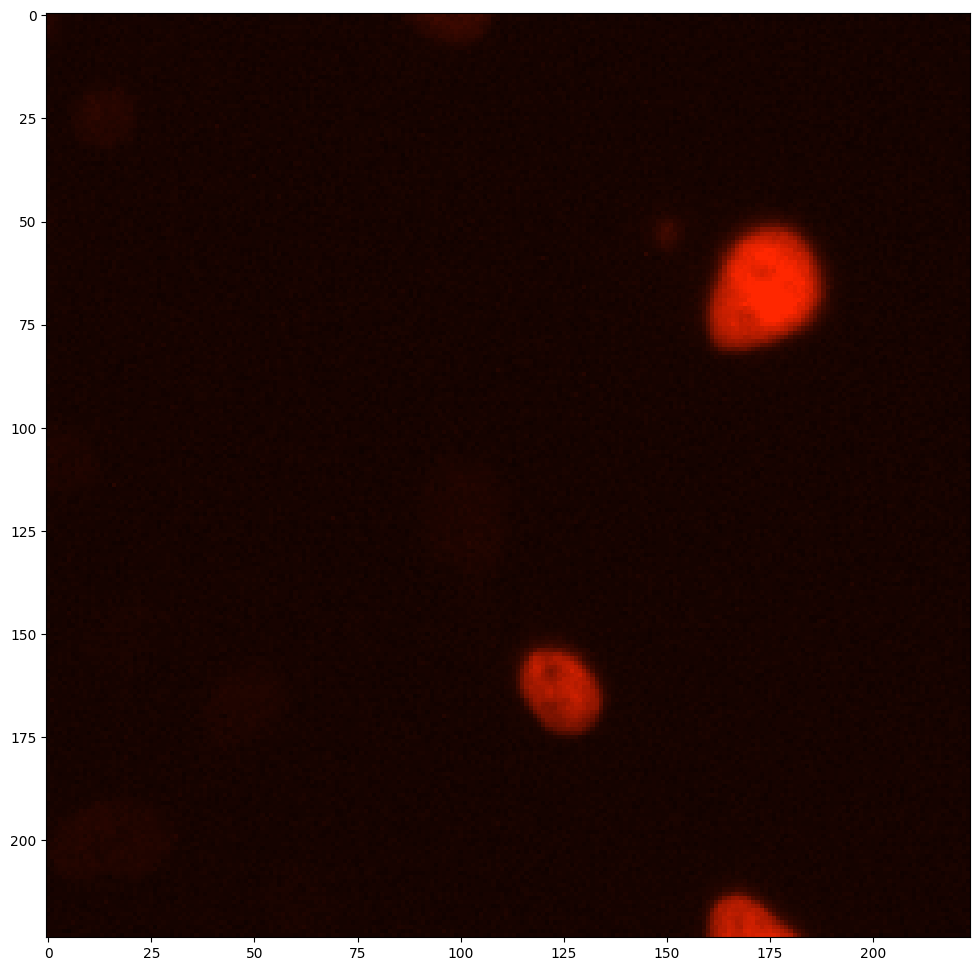

In [ ]:
import matplotlib.pyplot as plt

from torchvision.utils import draw_bounding_boxes, draw_segmentation_masks


image = read_image("/content/content/mCherryMask/images/mCherry-H2B_B2_1_2022y08m08d_13h45m-26.png")
eval_transform = get_transform(train=False)

model = maskrcnn_resnet50_fpn(weights=None)
model.load_state_dict(torch.load("/content/checkpoints/maskrcnn-resnet50-fpn-roi-nms-30.pt"))
model.eval()
model.to(torch.device('cuda'))
with torch.no_grad():
    x = eval_transform(image)
    # convert RGBA -> RGB and move to device
    x = x[:3, ...].to(torch.device('cuda'))
    predictions = model([x, ])
    pred = predictions[0]

print(pred)

image = (255.0 * (image - image.min()) / (image.max() - image.min())).to(torch.uint8)
image = image[:3, ...]
pred_labels = [f"mn: {score:.3f}" for label, score in zip(pred["labels"], pred["scores"])]
pred_boxes = pred["boxes"].long()
output_image = draw_bounding_boxes(image, pred_boxes, pred_labels, colors="red")

masks = (pred["masks"] > 0.7).squeeze(1)
output_image = draw_segmentation_masks(output_image, masks, alpha=0.5, colors="blue")


plt.figure(figsize=(12, 12))
plt.imshow(output_image.permute(1, 2, 0))

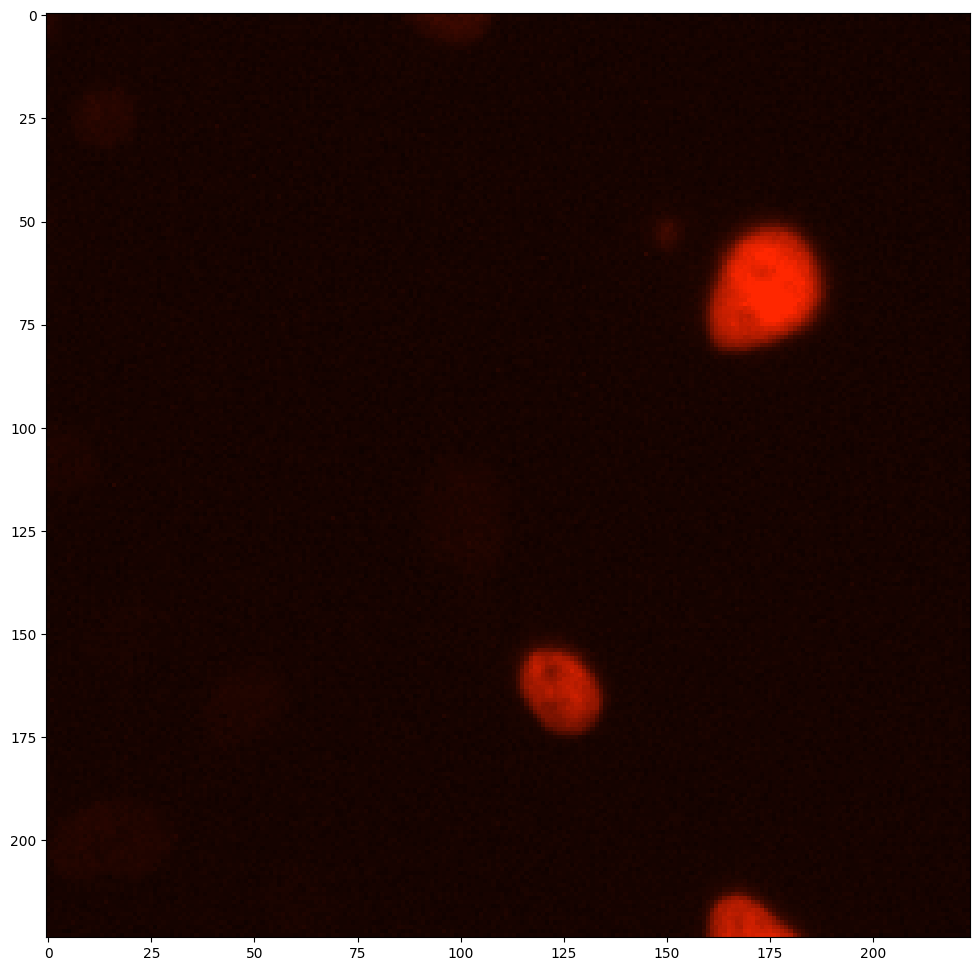

In [ ]:
img_path = "/content/content/mCherryMask/images/mCherry-H2B_B2_1_2022y08m08d_13h45m-26.png"
im = Image.open(img_path)
image = pil_to_tensor(im)
pred = app._predict(image)
pred_boxes,pred_masks,pred_scores = app._post_process(pred, 0.7)
len(pred_boxes)

image = (255.0 * (image - image.min()) / (image.max() - image.min())).to(torch.uint8)
image = image[:3, ...]
pred_labels = [f"mn: {score:.3f}" for score in pred_scores]
pred_boxes = pred_boxes.long()
output_image = draw_bounding_boxes(image, pred_boxes, pred_labels, colors="red")

masks = (pred_masks > 0.7).squeeze(1)
output_image = draw_segmentation_masks(output_image, masks, alpha=0.5, colors="blue")


plt.figure(figsize=(12, 12))
plt.imshow(output_image.permute(1, 2, 0))

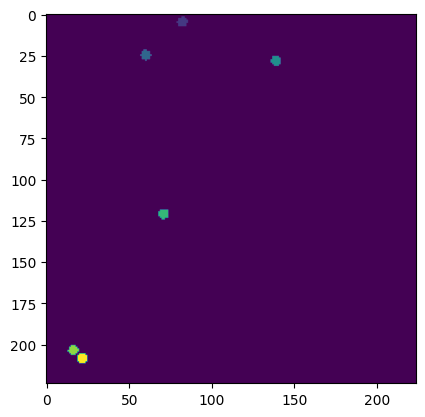

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

masks = np.load("/content/mnMask_v2/brush_masks/10 Gy_GFP-H2B_A1_3_2023y06m26d_00h57m-28.npy")
plt.imshow(masks)

### mcherry

In [ ]:
from mn_segmentation.tests.evaluator import Evaluator
from mn_segmentation.tests.test import evaluate_mn_dataset
from mn_segmentation.lib.Application import Application
from mn_segmentation.models.mask_rcnn import maskrcnn_mobile, maskrcnn_resnet, maskrcnn_resnet50_fpn, maskrcnn_swin

import os
from PIL import Image
import numpy as np
from torchvision.transforms.functional import pil_to_tensor
from tqdm import tqdm
import matplotlib.pyplot as plt
import argparse
import time

def evaluate_mn_dataset(model, dataset_path, evaluator, nms_iou=0.2, conf=0.4, mask_conf=0.7, ap_iou=0.5):
  for file in tqdm(os.listdir(os.path.join(dataset_path,'masks'))):
    # get final pred, may need customize model predict function
    im = Image.open(os.path.join(dataset_path,'images',file[:-4]+".png"))
    # im = im.convert("L")
    image = pil_to_tensor(im)
    pred = model._predict(image)
    pred_boxes,pred_masks,pred_scores = model._post_process(pred, conf)
    pred_boxes = pred_boxes.cpu().numpy()
    pred_masks = pred_masks.cpu().numpy()
    pred_masks = (pred_masks > mask_conf).squeeze(1)       # shape [n,w,h]
    pred_scores = pred_scores.cpu().numpy()           # shape [n]
    if pred_masks.ndim == 2:
      pred_masks = np.expand_dims(pred_masks, axis=0)
    # print(pred_masks.shape)
    # print(pred_scores.shape)

    # get GT mask
    gt_masks = np.load(os.path.join(dataset_path,'masks',file))  # shape [n,w,h]
    # obj_ids = np.unique(gt_masks)[1:]
    # gt_masks = (gt_masks == obj_ids[:, None, None])
    gt_masks.squeeze()
    if gt_masks.ndim == 2:
      gt_masks = np.expand_dims(gt_masks, axis=0)
    # if len(gt_masks) < 3:
    #   continue
    # compare and update
    recall = evaluator.update(pred_masks, pred_scores, gt_masks, ap_iou)

    # uncomment this can give bad cases that cause recall drop, missing mn
    # if recall < 0.5:
    #   print(recall,file)

  evaluator.finalize()
  # evaluator.draw_pr_curve()
  return

model = maskrcnn_resnet50_fpn(weights=None)
# model = maskrcnn_swin()
model.load_state_dict(torch.load("/content/drive/MyDrive/PMCC/checkpoints/maskrcnn-resnet50-jitter-v2-60-40.pt"))
app = Application(model=model, device=torch.device('cuda'))
evaluator = Evaluator()
for i in range(0,9):
  print(f"**********************************************")
  print(f"**** conf: {i/10} ************************")
  print("**********************************************")
  evaluator = Evaluator()
  for j in range(3,4):
    print(f"*********** mask_conf: {j/10} ************")
    evaluate_mn_dataset(app, "/content/content/mCherryMask/", evaluator, conf=i/10, mask_conf=j/10, ap_iou=0.10)

<ipython-input-11-4071ca4ff17f>:54: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("/content/drive/MyDrive/PMCC/checkpoints/maskrcnn-resnet50

**********************************************
**** conf: 0.0 ************************
**********************************************
*********** mask_conf: 0.3 ************


100%|██████████| 308/308 [00:15<00:00, 19.50it/s]


mAP: 0.8215561027676859
precision: 0.6483516483516484
recall: 0.989517819706499
f1: 0.783402489626556
**********************************************
**** conf: 0.1 ************************
**********************************************
*********** mask_conf: 0.3 ************


100%|██████████| 308/308 [00:15<00:00, 19.36it/s]


...

mAP: 0.8853953126927473
precision: 0.758985200845666
recall: 0.7526205450733753
f1: 0.7557894736842107
**********************************************
**** conf: 0.4 ************************
**********************************************
*********** mask_conf: 0.3 ************


100%|██████████| 308/308 [00:15<00:00, 19.57it/s]


mAP: 0.8942330769711576
precision: 0.7790432801822323
recall: 0.7169811320754716
f1: 0.7467248908296943
**********************************************
**** conf: 0.5 ************************
**********************************************
*********** mask_conf: 0.3 ************


 17%|█▋        | 52/308 [00:02<00:13, 19.46it/s]


KeyboardInterrupt: 

In [ ]:
app = Application(model=model2, device=torch.device('cuda'))
evaluator = Evaluator()
for i in range(5,9):
  print(f"**********************************************")
  print(f"**** conf: {i/10} ************************")
  print("**********************************************")
  evaluator = Evaluator()
  for j in range(5,9):
    print(f"*********** mask_conf: {j/10} ************")
    evaluate_mn_dataset(app, "/content/mnMask_v2/", evaluator, conf=i/10, mask_conf=j/10, ap_iou=0.25)

In [ ]:
app = Application(model=model3, device=torch.device('cuda'))
evaluator = Evaluator()
for i in range(5,9):
  print(f"**********************************************")
  print(f"**** conf: {i/10} ************************")
  print("**********************************************")
  evaluator = Evaluator()
  for j in range(5,9):
    print(f"*********** mask_conf: {j/10} ************")
    evaluate_mn_dataset(app, "/content/mnMask_v2/", evaluator, conf=i/10, mask_conf=j/10, ap_iou=0.25)

**********************************************
**** conf: 0.5 ************************
**********************************************
*********** mask_conf: 0.5 ************


100%|██████████| 200/200 [00:16<00:00, 12.06it/s]


mAP: 0.8458852300446386
precision: 0.6677852348993288
recall: 0.9731051344743277
f1: 0.7920398009950249
*********** mask_conf: 0.6 ************


100%|██████████| 200/200 [00:16<00:00, 12.26it/s]


mAP: 0.8504905190266216
precision: 0.6686241610738255
recall: 0.9743276283618582
f1: 0.7930348258706468
*********** mask_conf: 0.7 ************


...

mAP: 0.8911968908584691
precision: 0.7871621621621622
recall: 0.8545232273838631
f1: 0.8194607268464245
*********** mask_conf: 0.7 ************


100%|██████████| 200/200 [00:15<00:00, 12.50it/s]


mAP: 0.8924989622480085
precision: 0.7875375375375375
recall: 0.8549307253463733
f1: 0.8198515044939431
*********** mask_conf: 0.8 ************


100%|██████████| 200/200 [00:15<00:00, 12.51it/s]

mAP: 0.8931512007188851
precision: 0.7877252252252253
recall: 0.8551344743276283
f1: 0.8200468933177022


In [ ]:
from mn_segmentation.tests.evaluator import Evaluator
from mn_segmentation.tests.test import evaluate_mn_dataset
from mn_segmentation.lib.Application import Application

import os
from PIL import Image
import numpy as np
from torchvision.transforms.functional import pil_to_tensor
from tqdm import tqdm
import matplotlib.pyplot as plt
import argparse
import time

def evaluate_mn_dataset(model, dataset_path, evaluator, nms_iou=0.2, conf=0.4, mask_conf=0.7, ap_iou=0.5):
  for file in tqdm(os.listdir(os.path.join(dataset_path,'final_masks'))[-300:]):
    # get final pred, may need customize model predict function
    im = Image.open(os.path.join(dataset_path,'images',file[:-4]+".png"))
    image = pil_to_tensor(im)
    pred = model._predict(image)
    pred_boxes,pred_masks,pred_scores = model._post_process(pred, conf)
    pred_boxes = pred_boxes.cpu().numpy()
    pred_masks = pred_masks.cpu().numpy()
    pred_masks = (pred_masks > mask_conf).squeeze(1)       # shape [n,w,h]
    pred_scores = pred_scores.cpu().numpy()           # shape [n]
    if pred_masks.ndim == 2:
      pred_masks = np.expand_dims(pred_masks, axis=0)
    # print(pred_masks.shape)
    # print(pred_scores.shape)

    # get GT mask
    gt_masks = np.load(os.path.join(dataset_path,'final_masks',file))  # shape [n,w,h]
    # obj_ids = np.unique(gt_masks)[1:]
    # gt_masks = (gt_masks == obj_ids[:, None, None])
    gt_masks.squeeze()
    if gt_masks.ndim == 2:
      gt_masks = np.expand_dims(gt_masks, axis=0)
    # if len(gt_masks) < 4:
    #   continue
    # compare and update
    recall = evaluator.update(pred_masks, pred_scores, gt_masks, ap_iou)

    # uncomment this can give bad cases that cause recall drop, missing mn
    # if recall < 0.5:
    #   print(recall,file)

  evaluator.finalize()
  # evaluator.draw_pr_curve()
  return

model = maskrcnn_resnet50_fpn(weights=None)
model.load_state_dict(torch.load("/content/checkpoints/maskrcnn-resnet50-fpn-anchor-ablation-10.pt"))
app = Application(model=model, device=torch.device('cuda'))
evaluator = Evaluator()
for i in range(7,9):
  print(f"**********************************************")
  print(f"**** conf: {i/10} ************************")
  print("**********************************************")
  evaluator = Evaluator()
  for j in range(7,9):
    print(f"*********** mask_conf: {j/10} ************")
    evaluate_mn_dataset(app, "/content/mnMask_v2/", evaluator, conf=i/10, mask_conf=j/10, ap_iou=0.25)

<ipython-input-14-66a5933413d1>:51: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("/content/checkpoints/maskrcnn-resnet50-fpn-anchor-ablatio

**********************************************
**** conf: 0.7 ************************
**********************************************
*********** mask_conf: 0.7 ************


100%|██████████| 300/300 [00:17<00:00, 16.85it/s]


mAP: 0.8829978389228693
precision: 0.789983844911147
recall: 0.9022140221402214
f1: 0.8423772609819122
*********** mask_conf: 0.8 ************


 15%|█▌        | 46/300 [00:02<00:15, 16.23it/s]


KeyboardInterrupt: 

### review test set

In [ ]:
from collections import Counter
import os
import numpy as np

# Input and output directories
input_dir = "/content/mnMask/data/final_masks"

l = []
# Process each `.npy` file in the input directory
for file_name in os.listdir(input_dir)[-100:]:
    if file_name.endswith(".npy"):  # Check if it's an `.npy` file
        input_path = os.path.join(input_dir, file_name)
        mask = np.load(input_path)
        l.append(len(mask))

cnt = Counter(l)
cnt

Counter({2: 11, 1: 82, 4: 3, 5: 1, 3: 3})

In [ ]:
from mn_segmentation.tests.evaluator import Evaluator
from mn_segmentation.tests.test import evaluate_mn_dataset
from mn_segmentation.lib.Application import Application
from mn_segmentation.models.mask_rcnn import maskrcnn_mobile, maskrcnn_resnet, maskrcnn_resnet50_fpn
from torchvision.utils import draw_bounding_boxes, draw_segmentation_masks

import os
from PIL import Image
import numpy as np
from torchvision.transforms.functional import pil_to_tensor
from tqdm import tqdm
import matplotlib.pyplot as plt
import argparse
import time
import torch

def display_test(folder,app):
  total_label_red = 0
  total_label_grey = 0
  total_predict = 0
  true_predict = 0
  id = 0
  l = []
  for file in sorted(os.listdir(os.path.join(folder,'grey_masks'))):
    im = Image.open(os.path.join(folder,'images',file[:-4]+".png"))
    image = pil_to_tensor(im)
    pred = app._predict(image)
    pred_boxes,pred_masks,pred_scores = app._post_process(pred, 0.7)
    # pred_boxes = pred_boxes.cpu().numpy()
    pred_masks = pred_masks.cpu()
    pred_scores = pred_scores.cpu().numpy()

    image = (255.0 * (image - image.min()) / (image.max() - image.min())).to(torch.uint8)
    image = image[:3, ...]
    pred_labels = [f"mn: {score:.3f}" for score in pred_scores]
    pred_boxes = pred_boxes.long()
    output_image = draw_bounding_boxes(image, pred_boxes, pred_labels, colors="red")

    masks = (pred_masks > 0.7).squeeze(1)
    output_image = draw_segmentation_masks(output_image, masks, alpha=0.2, colors="blue")


    red_masks = np.load(os.path.join(folder,'red_masks',file))
    grey_masks = np.load(os.path.join(folder,'grey_masks',file))

    evaluator = Evaluator()
    recall = evaluator.update(masks, pred_scores, grey_masks, 0.5)
    print(f"objects: {evaluator.objects}, predictions: {evaluator.predictions}")
    print(f"TP: {evaluator.TP}, FP: {evaluator.FP}, FN: {evaluator.objects - evaluator.TP}")
    if evaluator.objects - evaluator.TP >= 1:
      l.append(id)
    id += 1

    if evaluator.objects != len(grey_masks):
      raise()
    total_label_red += len(red_masks)
    total_label_grey += len(grey_masks)
    total_predict += evaluator.predictions
    true_predict += evaluator.TP

    # Create a figure and arrange subplots in a single row
    fig, axes = plt.subplots(1, 4, figsize=(20, 10))

    # Plotting on each subplot
    axes[0].imshow(im.convert('L'))
    axes[1].imshow(output_image.permute(1, 2, 0))

    m = np.zeros((224,224))
    for mask in red_masks:
      m = m + mask
    print(m.shape)
    axes[2].imshow(m.squeeze())
    m = np.zeros((224,224))
    for mask in grey_masks:
      m = m + mask
    print(m.shape)
    axes[3].imshow(m.squeeze())
    plt.show()
  print(total_label_red,total_label_grey,total_predict,true_predict)
  print(l)



In [ ]:
folder = "/content/mCherryMask_v3"
# model = maskrcnn_resnet50_fpn(weights=None)
# model.load_state_dict(torch.load("/content/checkpoints/maskrcnn-resnet50-jitter-v2-60.pt"))
app = Application(device=torch.device('cuda'))
display_test(folder,app)

Output hidden; open in https://colab.research.google.com to view.

In [ ]:
l1 = [0, 4, 12, 14, 20, 22, 23, 24, 25, 36, 38, 43, 46, 47, 49, 54, 58, 60, 61, 62, 69, 71, 72, 77, 79, 82, 84, 86, 88, 90, 91, 94, 96, 99, 110, 115, 120, 122, 134, 139, 141, 142, 144, 145, 159, 169, 173, 174, 180, 181, 183, 186, 192, 193, 200, 204]
l2 = [0, 4, 6, 7, 12, 13, 14, 15, 16, 19, 20, 22, 23, 24, 25, 26, 28, 30, 35, 36, 38, 40, 42, 43, 45, 46, 47, 48, 49, 50, 54, 55, 57, 58, 59, 60, 61, 62, 63, 65, 67, 68, 69, 70, 71, 72, 74, 75, 76, 77, 79, 80, 81, 82, 84, 86, 87, 88, 89, 90, 91, 93, 94, 96, 97, 98, 99, 101, 103, 105, 108, 109, 110, 112, 115, 117, 120, 122, 126, 127, 128, 130, 131, 133, 134, 137, 139, 141, 142, 143, 144, 145, 148, 149, 151, 152, 153, 154, 155, 158, 159, 160, 161, 162, 163, 164, 166, 167, 169, 173, 174, 176, 177, 178, 180, 181, 183, 184, 185, 186, 187, 189, 190, 191, 192, 193, 194, 195, 199, 200, 201, 202, 204, 208, 209]

['mn: 0.933'] tensor(20)
<class 'torch.Tensor'> <class 'numpy.ndarray'>
tensor(True) tensor(0.4194) 0.41935483870967744
objects: 1, predictions: 1
TP: 0, FP: 1, FN: 1
(1, 224, 224)
(1, 224, 224)


<ipython-input-39-dcb7ec09ed48>:29: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  intersection = np.logical_and(pred_masks[i], gt_masks[j]).sum()
<ipython-input-39-dcb7ec09ed48>:30: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  union = np.logical_or(pred_masks[i], gt_masks[j]).sum()


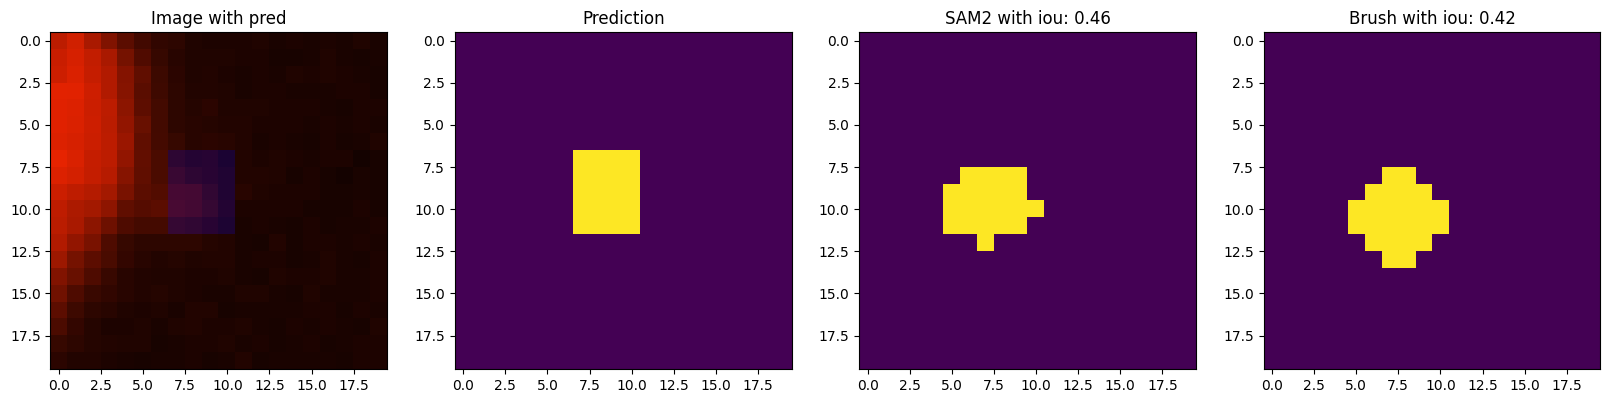

In [ ]:
# @title iou test

def calculate_iou(mask1, mask2):
    # Ensure masks are binary (0 or 1)
    mask1 = (mask1 > 0).astype(bool)
    mask2 = (mask2 > 0).astype(bool)

    # Calculate intersection and union
    intersection = np.logical_and(mask1, mask2).sum()
    union = np.logical_or(mask1, mask2).sum()

    if union == 0:
        return 0.0  # Avoid division by zero

    iou = intersection / union
    # miou = my_iou(mask1, mask2)
    # if iou != miou:
    #   raise()
    return iou


folder = "/content/mCherryMask_v3"
file = sorted(os.listdir(os.path.join(folder,"grey_masks")))[40]
app = Application(device=torch.device('cuda'))

im = Image.open(os.path.join(folder,'images',file[:-4]+".png"))
image = pil_to_tensor(im)
pred = app._predict(image)
pred_boxes,pred_masks,pred_scores = app._post_process(pred, 0.7)
# pred_boxes = pred_boxes.cpu().numpy()
pred_masks = pred_masks.cpu()
pred_scores = pred_scores.cpu().numpy()

image = (255.0 * (image - image.min()) / (image.max() - image.min())).to(torch.uint8)
image = image[:3, ...]
pred_labels = [f"mn: {score:.3f}" for score in pred_scores]
pred_boxes = pred_boxes.long()
# output_image = draw_bounding_boxes(image, pred_boxes, pred_labels, colors="red")

masks = (pred_masks > 0).squeeze(1)
output_image = draw_segmentation_masks(image, masks, alpha=0.2, colors="blue")
print(pred_labels, masks.sum())
red_masks = np.load(os.path.join(folder,'red_masks',file))
grey_masks = np.load(os.path.join(folder,'grey_masks',file))

evaluator = Evaluator()
recall = evaluator.update(masks, pred_scores, grey_masks, 0.5)
print(f"objects: {evaluator.objects}, predictions: {evaluator.predictions}")
print(f"TP: {evaluator.TP}, FP: {evaluator.FP}, FN: {evaluator.objects - evaluator.TP}")

# Create a figure and arrange subplots in a single row
fig, axes = plt.subplots(1, 4, figsize=(20, 10))

mn_wnd = 160, 120
sz = 20
pre_i, gtr_i, gtg_i = 0,0,0

# Plotting on each subplot
# axes[0].imshow(np.array(im)[105:125,200:220])
axes[0].title.set_text('Image with pred')
# axes[0].imshow(im.convert('L'))

axes[0].imshow(output_image.permute(1, 2, 0)[mn_wnd[0]:mn_wnd[0]+sz,mn_wnd[1]:mn_wnd[1]+sz])
axes[1].title.set_text('Prediction')
axes[1].imshow(masks[pre_i][mn_wnd[0]:mn_wnd[0]+sz,mn_wnd[1]:mn_wnd[1]+sz])

m = np.zeros((224,224))
for mask in red_masks:
  m = m + mask
print(red_masks.shape)
axes[2].imshow(red_masks[gtr_i].squeeze()[mn_wnd[0]:mn_wnd[0]+sz,mn_wnd[1]:mn_wnd[1]+sz])
axes[2].title.set_text(f'SAM2 with iou: {calculate_iou(masks[pre_i].numpy(),red_masks[gtr_i]):.2f}')

m = np.zeros((224,224))
for mask in grey_masks:
  m = m + mask
print(grey_masks.shape)
axes[3].imshow(grey_masks[gtg_i].squeeze()[mn_wnd[0]:mn_wnd[0]+sz,mn_wnd[1]:mn_wnd[1]+sz])
axes[3].title.set_text(f'Brush with iou: {calculate_iou(pred_masks[pre_i].numpy(),grey_masks[gtg_i]):.2f}')
plt.show()

In [ ]:
import numpy as np
import os

def calculate_iou(mask1, mask2):
    # Ensure masks are binary (0 or 1)
    mask1 = (mask1 > 0).astype(bool)
    mask2 = (mask2 > 0).astype(bool)

    # Calculate intersection and union
    intersection = np.logical_and(mask1, mask2).sum()
    union = np.logical_or(mask1, mask2).sum()

    if union == 0:
        return 0.0  # Avoid division by zero

    iou = intersection / union
    # miou = my_iou(mask1, mask2)
    # if iou != miou:
    #   raise()
    return iou

# Example usage
folder = "/content/mCherryMask_v4"
iou_l = []
for file in os.listdir(os.path.join(folder,'grey_masks')):
  refine_masks = np.load(os.path.join(folder,'refined_masks',file))
  if len(refine_masks.shape) >3: refine_masks= refine_masks.squeeze(1)
  grey_masks = np.load(os.path.join(folder,'grey_masks',file))
  if grey_masks.shape[0] != 1: continue
  iou_l.append(calculate_iou(refine_masks[0], grey_masks[0]))
print(np.mean(iou_l))
  # print(refine_masks.shape, refine_masks.dtype)
  # print(grey_masks.shape)
# print("IoU:", calculate_iou(red_masks[0], grey_masks[0]))

0.7228642863735755


In [ ]:
from mn_segmentation.tests.evaluator import Evaluator
from mn_segmentation.tests.test import evaluate_mn_dataset
from mn_segmentation.lib.Application import Application
from mn_segmentation.models.mask_rcnn import maskrcnn_mobile, maskrcnn_resnet, maskrcnn_resnet50_fpn, maskrcnn_swin

import os
from PIL import Image
import numpy as np
from torchvision.transforms.functional import pil_to_tensor
from tqdm import tqdm
import matplotlib.pyplot as plt
import argparse
import time

def evaluate_mn_dataset(model, dataset_path, evaluator, nms_iou=0.2, conf=0.4, mask_conf=0.7, ap_iou=0.5):
  for file in tqdm(os.listdir(os.path.join(dataset_path,'grey_masks'))):
    # get final pred, may need customize model predict function
    im = Image.open(os.path.join(dataset_path,'images',file[:-4]+".png"))
    # im = im.convert("L")
    image = pil_to_tensor(im)
    pred = model._predict(image)
    pred_boxes,pred_masks,pred_scores = model._post_process(pred, conf)
    pred_boxes = pred_boxes.cpu().numpy()
    pred_masks = pred_masks.cpu().numpy()
    pred_masks = (pred_masks > mask_conf).squeeze(1)       # shape [n,w,h]
    pred_scores = pred_scores.cpu().numpy()           # shape [n]
    if pred_masks.ndim == 2:
      pred_masks = np.expand_dims(pred_masks, axis=0)
    # print(pred_masks.shape)
    # print(pred_scores.shape)

    # get GT mask
    gt_masks = np.load(os.path.join(dataset_path,'grey_masks',file))  # shape [n,w,h]
    # obj_ids = np.unique(gt_masks)[1:]
    # gt_masks = (gt_masks == obj_ids[:, None, None])
    gt_masks.squeeze()
    if gt_masks.ndim == 2:
      gt_masks = np.expand_dims(gt_masks, axis=0)
    # if len(gt_masks) < 3:
    #   continue
    # compare and update
    recall = evaluator.update(pred_masks, pred_scores, gt_masks, ap_iou)

    # uncomment this can give bad cases that cause recall drop, missing mn
    # if recall < 0.5:
    #   print(recall,file)

  evaluator.finalize()
  # evaluator.draw_pr_curve()
  return

model = maskrcnn_resnet50_fpn(weights=None)
# model = maskrcnn_swin()
model.load_state_dict(torch.load("/content/drive/MyDrive/PMCC/checkpoints/maskrcnn-resnet50-jitter-v2-60-40.pt"))
app = Application(model=model, device=torch.device('cuda'))
evaluator = Evaluator()
for i in range(0,9):
  print(f"**********************************************")
  print(f"**** conf: {i/10} ************************")
  print("**********************************************")
  evaluator = Evaluator()
  for j in range(3,4):
    print(f"*********** mask_conf: {j/10} ************")
    evaluate_mn_dataset(app, "/content/mCherryMask_v3/", evaluator, conf=i/10, mask_conf=j/10, ap_iou=0.10)

**********************************************
**** conf: 0.0 ************************
**********************************************
*********** mask_conf: 0.3 ************


100%|██████████| 210/210 [00:10<00:00, 19.92it/s]


mAP: 0.9364063003335606
precision: 0.8126888217522659
recall: 0.8621794871794872
f1: 0.8367029548989113
**********************************************
**** conf: 0.1 ************************
**********************************************
*********** mask_conf: 0.3 ************


100%|██████████| 210/210 [00:10<00:00, 19.81it/s]


mAP: 0.8865478019663711
precision: 0.711453744493392
recall: 1.0352564102564104
f1: 0.8433420365535247
**********************************************
**** conf: 0.2 ************************
**********************************************
*********** mask_conf: 0.3 ************


...

mAP: 0.9453796674148318
precision: 0.8403908794788274
recall: 0.8269230769230769
f1: 0.8336025848142163
**********************************************
**** conf: 0.7 ************************
**********************************************
*********** mask_conf: 0.3 ************


100%|██████████| 210/210 [00:10<00:00, 20.13it/s]


mAP: 0.9511142070629485
precision: 0.8650519031141869
recall: 0.8012820512820513
f1: 0.831946755407654
**********************************************
**** conf: 0.8 ************************
**********************************************
*********** mask_conf: 0.3 ************


100%|██████████| 210/210 [00:10<00:00, 20.12it/s]

mAP: 0.9600241295061732
precision: 0.8918918918918919
recall: 0.7403846153846154
f1: 0.809106830122592


In [ ]:
import matplotlib.pyplot as plt
import os
from PIL import Image
import numpy as np
from multiprocessing import Pool
from tqdm import tqdm

def norm_img(gray_image):
  # Convert to NumPy array
  image_array = np.array(gray_image, dtype=np.float32)

  # Normalize to 0-1
  normalized_image = (image_array - np.min(image_array)) / (np.max(image_array) - np.min(image_array)) * 255
  normalized_image = normalized_image.astype(np.uint8)

  # Convert back to Image
  normalized_image_pil = Image.fromarray(normalized_image)
  return normalized_image_pil

def process_file(file):
  im = Image.open(os.path.join(folder,'images',file[:-4]+".png"))
  # gt_masks = np.load(os.path.join(folder,'final_masks',file))
  gray_image = norm_img(im.convert('L'))
  gray_image.save(os.path.join(folder,'grey_images',file[:-4]+".png"))

# save grey image
folder = "/content/mCherryMask"
os.makedirs(os.path.join(folder,'grey_images'),exist_ok=True)
# process_file("mCherry-H2B_B2_2_2022y08m08d_13h45m-1.png")
with Pool(4) as pool:
  file_lst = os.listdir(os.path.join(folder,'final_masks'))
  list(tqdm(pool.imap(process_file, file_lst), total=len(file_lst)))

# display examples
# folder = "/content/mCherryMask"
# for file in os.listdir(os.path.join(folder,'final_masks')):
#   im = Image.open(os.path.join(folder,'images',file[:-4]+".png"))
#   gt_masks = np.load(os.path.join(folder,'final_masks',file))
#   gray_image = norm_img(im.convert('L'))

  # # Create a figure and arrange subplots in a single row
  # fig, axes = plt.subplots(1, 3, figsize=(20, 10))

  # # Plotting on each subplot
  # gray_image = norm_img(im.convert('L'))
  # axes[0].imshow(gray_image)
  # axes[1].imshow(im)

  # m = np.zeros((224,224))
  # for mask in gt_masks:
  #   m = m + mask
  # print(m.shape)
  # axes[2].imshow(m.squeeze())
  # plt.show()

100%|██████████| 308/308 [00:00<00:00, 391.71it/s]


In [ ]:
# len(os.listdir(os.path.join(folder,'grey_images')))
# !rm -r /content/mCherryMask/grey_images
!zip -r mCherryMask_v2.zip mCherryMask/
!cp /content/mCherryMask_v2.zip /content/drive/MyDrive/PMCC/Dataset/

  adding: mCherryMask/ (stored 0%)
  adding: mCherryMask/final_masks/ (stored 0%)
  adding: mCherryMask/final_masks/mCherry-H2B_E3_1_2022y08m08d_13h45m-0.npy (deflated 100%)
  adding: mCherryMask/final_masks/mCherry-H2B_E5_2_2022y08m08d_13h45m-21.npy (deflated 100%)
  adding: mCherryMask/final_masks/mCherry-H2B_C4_2_2022y08m08d_13h45m-29.npy (deflated 100%)
  adding: mCherryMask/final_masks/mCherry-H2B_D6_2_2022y08m08d_13h45m-14.npy (deflated 100%)
  adding: mCherryMask/final_masks/mCherry-H2B_E5_3_2022y08m08d_13h45m-6.npy (deflated 100%)
  adding: mCherryMask/final_masks/mCherry-H2B_E7_2_2022y08m08d_13h45m-18.npy (deflated 100%)
  adding: mCherryMask/final_masks/mCherry-H2B_E7_4_2022y08m08d_13h45m-21.npy (deflated 100%)
  adding: mCherryMask/final_masks/mCherry-H2B_B3_2_2022y08m08d_13h45m-1.npy (deflated 100%)
  adding: mCherryMask/final_masks/mCherry-H2B_B2_3_2022y08m08d_13h45m-27.npy (deflated 100%)
  adding: mCherryMask/final_masks/mCherry-H2B_D4_1_2022y08m08d_13h45m-24.npy (deflat

# Color exp

## count images used in training

In [ ]:
!cp /content/drive/MyDrive/PMCC/Dataset/mnMask_v2.zip /content/
!unzip /content/mnMask_v2.zip

Streaming output truncated to the last 5000 lines.
  inflating: mnMask_v2/brush_masks/GFP-H2B_A1_3_2023y07m01d_03h02m-8.npy  
  inflating: mnMask_v2/brush_masks/10 Gy_GFP-H2B_B1_2_2023y06m25d_08h17m_0.npy  
  inflating: mnMask_v2/brush_masks/GFP-H2B_A3_4_2023y06m30d_17h02m-10.npy  
  inflating: mnMask_v2/brush_masks/10 Gy_GFP-H2B_A2_1_2023y06m25d_08h17m_0.npy  
  inflating: mnMask_v2/brush_masks/GFP-H2B_A1_4_2023y07m03d_08h02m-9.npy  
  inflating: mnMask_v2/brush_masks/Plate 1_GFP-H2B_N2_1_2022y12m02d_23h30m-11.npy  
  inflating: mnMask_v2/brush_masks/10 Gy_GFP-H2B_A1_2_2023y06m23d_22h57m-0.npy  
  inflating: mnMask_v2/brush_masks/GFP-H2B_A1_3_2023y06m30d_12h02m-8.npy  
  inflating: mnMask_v2/brush_masks/GFP-H2B_A3_2_2023y06m30d_20h02m-18.npy  
  inflating: mnMask_v2/brush_masks/GFP-H2B_A2_2_2023y07m01d_02h02m-5.npy  
  inflating: mnMask_v2/brush_masks/10 Gy_GFP-H2B_A1_1_2023y06m25d_16h17m_2.npy  
  inflating: mnMask_v2/brush_masks/Plate 1_GFP-H2B_E17_1_2022y12m02d_03h30m-21.npy  
  in

In [ ]:
import os
from collections import defaultdict

folder = "/content/mnMask_v2/final_masks"
count = 0
header = defaultdict(int)
for file in os.listdir(folder):
  if file.split("_")[0] == "10 Gy" and "17m" in file:
    count += 1
  header[file.split("_")[0]] += 1

print(count)
print(header)

271
defaultdict(<class 'int'>, {'10 Gy': 554, 'GFP-H2B': 1105, 'Plate 1': 156, 'Plate 2': 14})


In [ ]:
# install tool
%cd /content/
!git clone https://github.com/kew6688/MicroNuclei_Detection.git
!pip install -e MicroNuclei_Detection/.
!pip show mn_segmentation
%cd /content/MicroNuclei_Detection

!cd checkpoints && \
./download_ckpts.sh

/content
Cloning into 'MicroNuclei_Detection'...
remote: Enumerating objects: 707, done.
remote: Counting objects: 100% (101/101), done.
remote: Compressing objects: 100% (80/80), done.
remote: Total 707 (delta 68), reused 42 (delta 21), pack-reused 606 (from 1)
Receiving objects: 100% (707/707), 28.50 MiB | 21.60 MiB/s, done.
Resolving deltas: 100% (424/424), done.
Obtaining file:///content/MicroNuclei_Detection
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
  Building editable for mn_segmentation (pyproject.toml) ... done
  Created wheel for mn_segmentation: filename=mn_segmentation-0.1.0-py2.py3-none-any.whl size=5206 sha256=5ef2b12ef546e37f0d1909d4779224f21175a33bb42e5a0c4f7789b31bc72572
  Stored in directory: /tmp/pip-ephem-wheel-cache-xrel6izx/wheels/3f/81/01/c4f05b68a1cbc02396527f710866e1b4827249f9a5d7d4b505
Successfully

In [ ]:
from mn_segmentation.tests.evaluator import Evaluator
from mn_segmentation.tests.test import evaluate_mn_dataset
from mn_segmentation.lib.Application import Application
from PIL import Image
import numpy as np
from torchvision.transforms.functional import pil_to_tensor
from tqdm import tqdm
import matplotlib.pyplot as plt
import argparse
import time
import torch

def predict_image_info(self, image_path, conf=0.7, footer_skip=False):
  im = Image.open(image_path)

  output = {"coord":[], "area":[], "bbox":[], "score":[], "mask":[]}

  # crop image to model input size 224x224
  wnd_sz = 200
  height, width = np.array(im).shape[:2]

  output["height"] = height
  output["width"] = width

  # calculate how many rows and cols to cover the image, contain last row and col
  for i in range(height // wnd_sz + 1):
    for j in range(width // wnd_sz + 1):
      # skip footer in Kate's images, row and col is 5x7
      if footer_skip and i*7+j in [28,29,33,34]: continue

      # tile image
      cur_x, cur_y = wnd_sz * j, wnd_sz * i
      box = (cur_x, cur_y, cur_x + wnd_sz, cur_y + wnd_sz)

      image = pil_to_tensor(im.crop(box))
      pred = self._predict(image)

      pred_boxes, pred_masks, pred_scores= self._post_process(pred, conf)
      pred_boxes[:, [0,2]] += cur_x
      pred_boxes[:, [1,3]] += cur_y
      area = pred_masks.sum(1).sum(1).sum(1)
      # print(area.shape)

      output["bbox"] += pred_boxes.cpu().numpy().tolist()
      # output["coord"] += cluster.boxToCenters(pred_boxes).tolist()
      output["area"] += area.cpu().numpy().tolist()
      output["score"] += pred_scores.cpu().numpy().tolist()

      pred_masks = pred_masks.cpu().type(torch.float32).numpy().squeeze(1)
      for mask_i in range(pred_masks.shape[0]):
        # Create an empty array of the same size as the image to hold the masks
        output_mask = np.zeros((height, width), dtype=np.uint8)

        m = (pred_masks[mask_i] > conf)[:height-cur_y, :width-cur_x]
        # print(height-cur_y)
        output_mask[cur_y: cur_y+wnd_sz, cur_x: cur_x+wnd_sz][m] = 1



app = Application()
for file in tqdm(os.listdir("/content/mnMask_v2/images")[-300:]):
  predict_image_info(app, "/content/mnMask_v2/images/"+file)

100%|██████████| 300/300 [00:57<00:00,  5.21it/s]


In [ ]:
from mn_segmentation.tests.evaluator import Evaluator
from mn_segmentation.tests.test import evaluate_mn_dataset
from mn_segmentation.lib.Application import Application
import shutil

source_folder = "/content/mnMask_v2/final_masks"
destination_folder = "/content/color_test"
os.makedirs(destination_folder, exist_ok=True)
os.makedirs(destination_folder+"/images", exist_ok=True)
os.makedirs(destination_folder+"/final_masks", exist_ok=True)

app = Application()
s = set()
for filename in tqdm(os.listdir(source_folder)):
  s.add(filename.split("_")[0])
  if filename.split("_")[0] != "Plate 1":
    continue

  source_mask_path = os.path.join(source_folder, filename)
  destination_mask_path = os.path.join(destination_folder+"/final_masks", filename)
  source_img_path = os.path.join("/content/mnMask_v2/images", filename.replace("npy", "png"))
  destination_img_path = os.path.join("/content/color_test/images", filename.replace("npy", "png"))

  # Copy the file
  shutil.copy2(source_mask_path, destination_mask_path)
  shutil.copy2(source_img_path, destination_img_path)

s

100%|██████████| 1829/1829 [00:00<00:00, 13713.10it/s]


{'10 Gy', 'GFP-H2B', 'Plate 1', 'Plate 2'}

In [ ]:
print("========================")
print("====== Green ========")
print("========================")
gre_f1 = []
for i in range(10):
    print(f"**********************************************")
    print(f"**** conf: {i/10} ************************")
    print("**********************************************")
    evaluator = Evaluator()
    evaluate_mn_dataset(app, dataset_path, evaluator, conf=i/10, ap_iou=0.5)

Print("========================")
Print("====== Red ========")
Print("========================")

for i in range(10):
    print(f"**********************************************")
    print(f"**** conf: {i/10} ************************")
    print("**********************************************")
    evaluator = Evaluator()
    evaluate_mn_dataset(app, dataset_path, evaluator, conf=i/10, ap_iou=0.5)

Print("========================")
Print("====== Blue ========")
Print("========================")
evaluator = Evaluator()
for i in range(10):
    print(f"**********************************************")
    print(f"**** conf: {i/10} ************************")
    print("**********************************************")
    evaluator = Evaluator()
    evaluate_mn_dataset(app, dataset_path, evaluator, conf=i/10, ap_iou=0.5)

Print("========================")
Print("====== Grey ========")
Print("========================")
evaluator = Evaluator()
for i in range(10):
    print(f"**********************************************")
    print(f"**** conf: {i/10} ************************")
    print("**********************************************")
    evaluator = Evaluator()
    evaluate_mn_dataset(app, dataset_path, evaluator, conf=i/10, ap_iou=0.5)

====== Green ========


100%|██████████| 100/100 [00:05<00:00, 18.43it/s]

mAP: 0.9716901125034425
precision: 0.8475836431226765
recall: 0.912
f1: 0.8786127167630058


# Count flops and time

In [ ]:
!pip install fvcore

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.2/50.2 kB 1.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.2/42.2 kB 104.6 kB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for fvcore: filename=fvcore-0.1.5.post20221221-py3-none-any.whl size=61396 sha256=055fd12df10a77d8c668962ef7fd893261d052c9c8b67d3a917f8038610dc98d
  Stored in directory: /root/.cache/pip/wheels/65/71/95/3b8fde5c65c6e4a806e0867c1651dcc71a1cb2f3430e8f355f
  Created wheel for iopath: filename=iopath-0.1.10-py3-none-any.whl size=31528 sha256=9e736fe25366d475c39194d4ba547081faf434f6e5154e16892646d138630e08
  Stored in directory: /root/.cache/pip/wheels/ba/5e/16/6117f8fe7e9c0c161a795e10d94645ebcf301ccbd01f66d8ec
Successfully built fvcore iopath


In [ ]:
!cp /content/drive/MyDrive/PMCC/Analysis/Ulises_counts_all.zip /content/
!unzip /content/Ulises_counts_all.zip

Archive:  /content/Ulises_counts_all.zip
   creating: content/Ulises_counts/
   creating: content/Ulises_counts/Day 6 tif/
  inflating: content/Ulises_counts/Day 6 tif/VID3664_E6_3_2024y08m06d_11h44m.tif  
  inflating: content/Ulises_counts/Day 6 tif/VID3664_B6_2_2024y08m06d_11h44m.tif  
  inflating: content/Ulises_counts/Day 6 tif/VID3664_A5_2_2024y08m06d_11h44m.tif  
  inflating: content/Ulises_counts/Day 6 tif/VID3664_A4_3_2024y08m06d_11h44m.tif  
  inflating: content/Ulises_counts/Day 6 tif/VID3664_E6_4_2024y08m06d_11h44m.tif  
  inflating: content/Ulises_counts/Day 6 tif/VID3664_B5_4_2024y08m06d_11h44m.tif  
  inflating: content/Ulises_counts/Day 6 tif/VID3664_A6_4_2024y08m06d_11h44m.tif  
  inflating: content/Ulises_counts/Day 6 tif/VID3664_C5_1_2024y08m06d_11h44m.tif  
  inflating: content/Ulises_counts/Day 6 tif/VID3664_E4_3_2024y08m06d_11h44m.tif  
  inflating: content/Ulises_counts/Day 6 tif/VID3664_C5_4_2024y08m06d_11h44m.tif  
  inflating: content/Ulises_counts/Day 6 tif/VI

In [ ]:
!cp /content/drive/MyDrive/PMCC/checkpoints/maskrcnn-swin-fpn-200.pt /content/

In [ ]:
!cd checkpoints && \
./download_ckpts.sh && \
cd ..

--2025-02-06 09:02:45--  https://huggingface.co/kew1046/MaskRCNN-resnet50FPN/resolve/main/maskrcnn-resnet50fpn.pt
Resolving huggingface.co (huggingface.co)... 18.164.174.23, 18.164.174.55, 18.164.174.118, ...
Connecting to huggingface.co (huggingface.co)|18.164.174.23|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://cdn-lfs-us-1.hf.co/repos/b8/2d/b82d6d86c56c50a4e8010db25fad211aff4bf513798d94016f40a96c816e1192/3033f107b2b991e020020842bf9c827e59f4985efd340beaf03b14260d4fba3e?response-content-disposition=inline%3B+filename*%3DUTF-8%27%27maskrcnn-resnet50fpn.pt%3B+filename%3D%22maskrcnn-resnet50fpn.pt%22%3B&Expires=1738836165&Policy=eyJTdGF0ZW1lbnQiOlt7IkNvbmRpdGlvbiI6eyJEYXRlTGVzc1RoYW4iOnsiQVdTOkVwb2NoVGltZSI6MTczODgzNjE2NX19LCJSZXNvdXJjZSI6Imh0dHBzOi8vY2RuLWxmcy11cy0xLmhmLmNvL3JlcG9zL2I4LzJkL2I4MmQ2ZDg2YzU2YzUwYTRlODAxMGRiMjVmYWQyMTFhZmY0YmY1MTM3OThkOTQwMTZmNDBhOTZjODE2ZTExOTIvMzAzM2YxMDdiMmI5OTFlMDIwMDIwODQyYmY5YzgyN2U1OWY0OTg1ZWZkMzQwYmVhZjAzYjE0

In [ ]:
# @title flops
from fvcore.nn import FlopCountAnalysis
import torchvision
from PIL import Image
import torch
import torchvision.transforms as T
from mn_segmentation.models.mask_rcnn import maskrcnn_mobile, maskrcnn_resnet, maskrcnn_resnet50_fpn, maskrcnn_swin

# model = maskrcnn_resnet("resnext101_32x8d", num_classes=2, pretrained=True)
model = maskrcnn_swin()
model.load_state_dict(torch.load("/content/maskrcnn-swin-fpn-200.pt"))
model.eval()
img_path = "/content/Ulises_counts/Day 6 count/VID3664_B5_1_2024y08m06d_11h44m.jpg"
img = Image.open(img_path)
transform = T.Compose([T.CenterCrop(224),T.ToTensor()])
img = transform(img)
# pred = model([img])
flops = FlopCountAnalysis(model, [img])
flops.total()

Using maskrcnn with swin backbone...
[128, 256, 512, 1024]


<ipython-input-12-6dd7eec006ce>:11: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("/content/maskrcnn-swin-fpn-200.pt"))
/usr/local/lib/pytho

35028388096

In [ ]:
# @title parameters

custom_model = maskrcnn_swin()
custom_model.load_state_dict(torch.load("/content/maskrcnn-swin-fpn-200.pt"))

# Count parameters
total_params = sum(p.numel() for p in custom_model.parameters())
trainable_params = sum(p.numel() for p in custom_model.parameters() if p.requires_grad)

print(f"Total Parameters: {total_params:,}")
print(f"Trainable Parameters: {trainable_params:,}")

Using maskrcnn with swin backbone...
[128, 256, 512, 1024]


<ipython-input-30-f49411f40119>:4: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  custom_model.load_state_dict(torch.load("/content/maskrcnn-swin-fpn-200.pt"))


Total Parameters: 106,719,709
Trainable Parameters: 106,719,709


In [ ]:
# @title time

import torch
from mn_segmentation.lib.Application import Application
from mn_segmentation.models.mask_rcnn import maskrcnn_mobile, maskrcnn_resnet, maskrcnn_resnet50_fpn, maskrcnn_swin
import os
import time
from tqdm import tqdm

# model = maskrcnn_resnet50_fpn(weights=None)
# model.load_state_dict(torch.load("/content/checkpoints/maskrcnn-resnet50-jitter-v2-60-40.pt"))

# model = maskrcnn_swin()
# model.load_state_dict(torch.load("/content/maskrcnn-swin-fpn-200.pt"))

model = maskrcnn_resnet("resnext101_32x8d", num_classes=2, pretrained=True)
app = Application(model=model, device=torch.device('cuda'))

pred = [[],[]]
tc = 0
folders = ["/content/Ulises_counts/Day 3 count", "/content/Ulises_counts/Day 6 count"]
for i in range(1):
  folder = folders[i]
  image_paths = sorted(os.listdir(folder))

  for image_path in tqdm(image_paths[:20]):
     if image_path[:2] == "._": continue
     start = time.time()
     cnt = app.predict_image_count(os.path.join(folder,image_path),True,0.8,True)
    #  print(f"{image_path} {time.time()-start}")
     tc += time.time()-start
     pred[i].append(cnt)
print(tc/20)

Using maskrcnn with resnext101_32x8d backbone...


/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:135: UserWarning: Using 'backbone_name' as positional parameter(s) is deprecated since 0.13 and may be removed in the future. Please use keyword parameter(s) instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNeXt101_32X8D_Weights.IMAGENET1K_V1`. You can also use `weights=ResNeXt101_32X8D_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
100%|██████████| 20/20 [01:04<00:00,  3.20s/it]

3.203629803657532
